# 🔬 MBDA Assignment 1 — EDA & Machine Learning Pipeline
## Dataset: BreastCancerData.csv
### Models: XGBoost · Random Forest · SVM · ANN (PyTorch)
---
> **Pipeline Stages:** Data Loading → Integrity Check → EDA (Histograms, Box Plots, Violin, Outlier, Correlation) → Feature Selection (Yeo-Johnson, ANOVA/MI, Multicollinearity) → PCA → Preprocessing (SMOTE, Scaling) → Training (GPU-Accelerated) → Evaluation (Confusion Matrix, ROC, PR Curve) → Model Comparison

## ⚙️ SECTION 0: Setup, Import & GPU Detection

In [55]:
import warnings
warnings.filterwarnings('ignore')

# ── Core ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import math
import time

# ── Visualization ─────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ── Statistics & Preprocessing ────────────────────────────
import scipy.stats as stats
from sklearn.preprocessing import (StandardScaler, LabelEncoder,
                                    PowerTransformer, MinMaxScaler)
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.model_selection import learning_curve, StratifiedKFold

# ── Imbalanced ────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── ML Models ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

# ── Deep Learning ─────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

# ── Evaluation ────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score
)

# ── cuML GPU (optional) ───────────────────────────────────
try:
    import cuml
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.svm import SVC as cuSVC
    CUML_AVAILABLE = True
    print("✅ cuML (RAPIDS GPU) tersedia — RF & SVM akan menggunakan GPU!")
except ImportError:
    CUML_AVAILABLE = False
    print("⚠️  cuML tidak tersedia — RF & SVM menggunakan sklearn (CPU).")
    print("   Untuk mengaktifkan GPU di RF/SVM, install: pip install cuml-cu12")

# ── Global Style ──────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.max_open_warning': 0,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

# ── Color Palette (consistent across all plots) ───────────
PALETTE = {'B': '#2ecc71', 'M': '#e74c3c'}   # Benign=Green, Malignant=Red
COLORS  = ['#2ecc71', '#e74c3c']

print("✅ Semua library berhasil diimport!")

⚠️  cuML tidak tersedia — RF & SVM menggunakan sklearn (CPU).
   Untuk mengaktifkan GPU di RF/SVM, install: pip install cuml-cu12
✅ Semua library berhasil diimport!


In [56]:
# ════════════════════════════════════════════════════════════
#  GPU DETECTION & DEVICE SETUP
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("🔧  DETEKSI GPU & DEVICE SETUP")
print("=" * 60)

# PyTorch CUDA
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')
print(f"PyTorch Device   : {DEVICE}")

if CUDA_AVAILABLE:
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU Model        : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version     : {torch.version.cuda}")
    print(f"VRAM Total       : {gpu_props.total_memory / 1e9:.2f} GB")
    print(f"SM Count         : {gpu_props.multi_processor_count}")
    XGB_DEVICE = 'cuda'
    print("\n✅ XGBoost  → GPU (device='cuda')")
    print("✅ ANN      → GPU (torch.device('cuda'))")
    if CUML_AVAILABLE:
        print("✅ RF / SVM → GPU (cuML)")
    else:
        print("⚠️  RF / SVM → CPU (sklearn) — cuML belum terinstall")
else:
    XGB_DEVICE = 'cpu'
    print("⚠️  CUDA tidak terdeteksi. Semua model akan berjalan di CPU.")

print("=" * 60)

# Random seeds untuk reproduktibilitas
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if CUDA_AVAILABLE:
    torch.cuda.manual_seed_all(SEED)

🔧  DETEKSI GPU & DEVICE SETUP
PyTorch Device   : cuda
GPU Model        : NVIDIA GeForce RTX 4050 Laptop GPU
CUDA Version     : 13.0
VRAM Total       : 6.44 GB
SM Count         : 20

✅ XGBoost  → GPU (device='cuda')
✅ ANN      → GPU (torch.device('cuda'))
⚠️  RF / SVM → CPU (sklearn) — cuML belum terinstall


## 📂 SECTION 1: Data Loading & Inspeksi Awal

In [57]:
# ── Load Dataset ──────────────────────────────────────────
FILE_PATH = "BreastCancerData (4).csv"
TARGET_COL = 'diagnosis'

try:
    df = pd.read_csv(FILE_PATH)
    print(f"✅ Dataset berhasil dimuat!")
    print(f"   Dimensi awal : {df.shape[0]} baris × {df.shape[1]} kolom")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ File tidak ditemukan: {FILE_PATH}. Pastikan file ada di direktori yang sama.")

# Drop kolom unnamed terakhir jika ada (artefak CSV)
unnamed_cols = [c for c in df.columns if 'Unnamed' in str(c)]
if unnamed_cols:
    df.drop(columns=unnamed_cols, inplace=True)
    print(f"   Kolom dihapus : {unnamed_cols}")

# Drop kolom 'id' jika ada (tidak relevan untuk ML)
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
    print("   Kolom 'id' dihapus (tidak relevan)")

print(f"\n   Dimensi bersih : {df.shape[0]} baris × {df.shape[1]} kolom")
print("\n📋 5 Baris Pertama:")
display(df.head())

print("\n📋 Info Umum DataFrame:")
df.info()

✅ Dataset berhasil dimuat!
   Dimensi awal : 569 baris × 33 kolom
   Kolom dihapus : ['Unnamed: 32']
   Kolom 'id' dihapus (tidak relevan)

   Dimensi bersih : 569 baris × 31 kolom

📋 5 Baris Pertama:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



📋 Info Umum DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se      

## 🔍 SECTION 2: Data Integrity Check

In [58]:
print("=" * 60)
print("🔍  DATA INTEGRITY CHECK")
print("=" * 60)

# ── 1. Missing Values ─────────────────────────────────────
missing = df.isnull().sum()
print("\n[1] MISSING VALUES:")
if missing.sum() == 0:
    print("   ✅ Tidak ada missing values.")
else:
    print(missing[missing > 0])
    df.dropna(inplace=True)
    print(f"   ⚠️  Missing values ditemukan & di-drop. Dimensi baru: {df.shape}")

# ── 2. Duplikat ───────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"\n[2] DUPLIKAT: {dupes} baris duplikat")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"   ✅ Duplikat dihapus. Dimensi baru: {df.shape}")
else:
    print("   ✅ Tidak ada duplikat.")

# ── 3. Tipe Data ──────────────────────────────────────────
non_num = df.select_dtypes(exclude=[np.number]).columns.tolist()
non_num_clean = [c for c in non_num if c != TARGET_COL]
print(f"\n[3] KOLOM NON-NUMERIK (selain target): {non_num_clean if non_num_clean else 'Tidak ada ✅'}")

# ── 4. Statistik Deskriptif ───────────────────────────────
print("\n[4] STATISTIK DESKRIPTIF FITUR NUMERIK:")
display(df.describe().T.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .format(precision=3)
)

print("\n✅ Data Integrity Check selesai!")

🔍  DATA INTEGRITY CHECK

[1] MISSING VALUES:
   ✅ Tidak ada missing values.

[2] DUPLIKAT: 0 baris duplikat
   ✅ Tidak ada duplikat.

[3] KOLOM NON-NUMERIK (selain target): Tidak ada ✅

[4] STATISTIK DESKRIPTIF FITUR NUMERIK:


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.000,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.000,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.000,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.000,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.000,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.000,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave points_mean,569.000,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.000,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.000,0.063,0.007,0.050,0.058,0.062,0.066,0.097



✅ Data Integrity Check selesai!


## 📊 SECTION 3: EDA — Distribusi Kelas Target

[Target: 'diagnosis']
  Benign (B)    : 357 sampel
  Malignant (M) : 212 sampel
  Imbalance Ratio: 1.68x  ⚠️ Perlu SMOTE


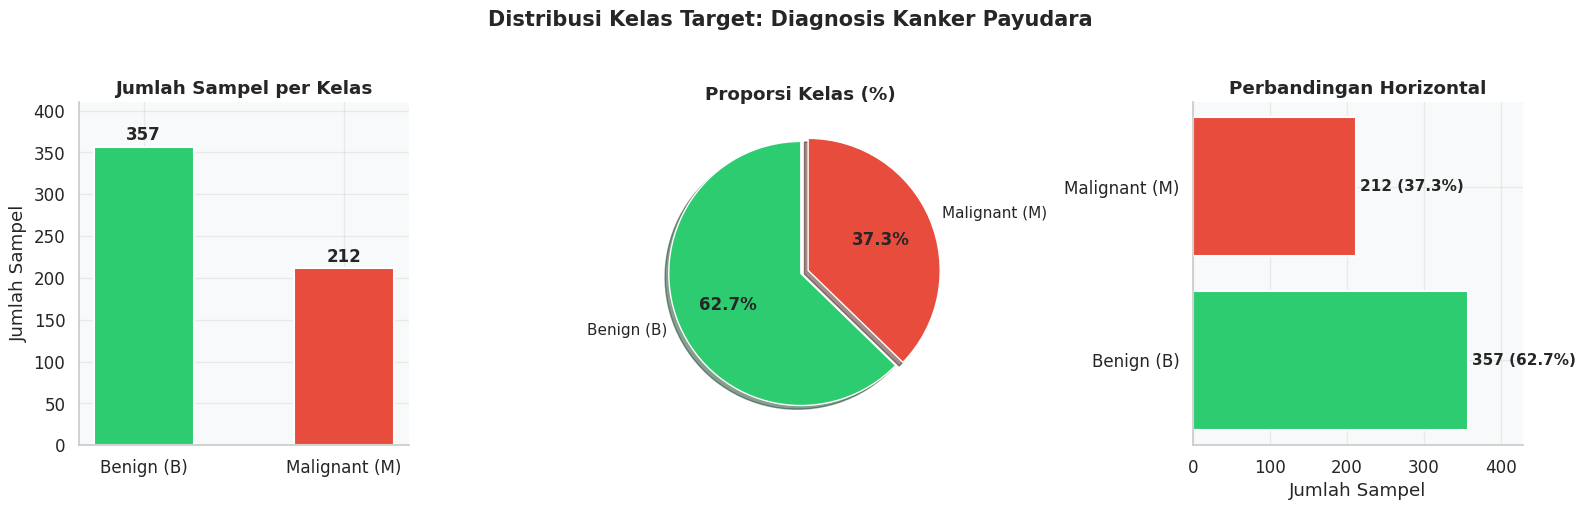

✅ Visualisasi distribusi kelas selesai.


In [59]:
label_counts = df[TARGET_COL].value_counts().sort_index()
print(f"[Target: '{TARGET_COL}']")
print(f"  Benign (B)    : {label_counts.get('B', 0)} sampel")
print(f"  Malignant (M) : {label_counts.get('M', 0)} sampel")
imbalance_ratio = label_counts.max() / label_counts.min()
print(f"  Imbalance Ratio: {imbalance_ratio:.2f}x  {'⚠️ Perlu SMOTE' if imbalance_ratio > 1.5 else '✅ Cukup Seimbang'}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribusi Kelas Target: Diagnosis Kanker Payudara",
             fontsize=15, fontweight='bold', y=1.02)

# Bar chart
bars = axes[0].bar(['Benign (B)', 'Malignant (M)'],
                   label_counts.values, color=COLORS, edgecolor='white',
                   linewidth=1.5, width=0.5)
axes[0].set_title('Jumlah Sampel per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, label_counts.max() * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=['Benign (B)', 'Malignant (M)'],
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=90,
    explode=(0, 0.06),
    shadow=True,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Proporsi Kelas (%)', fontweight='bold')

# Horizontal bar chart dengan annotation
cats = ['Benign (B)', 'Malignant (M)']
vals = label_counts.values
hbars = axes[2].barh(cats, vals, color=COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(hbars, vals):
    axes[2].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(df)*100:.1f}%)',
                 va='center', fontweight='bold', fontsize=11)
axes[2].set_title('Perbandingan Horizontal', fontweight='bold')
axes[2].set_xlabel('Jumlah Sampel')
axes[2].set_xlim(0, vals.max() * 1.2)

plt.tight_layout()
plt.show()
print("✅ Visualisasi distribusi kelas selesai.")

## 📈 SECTION 4: EDA — Distribusi Fitur (Histogram + KDE per Batch)

📊 Visualisasi 30 fitur dalam 4 batch (grid 3×3)...


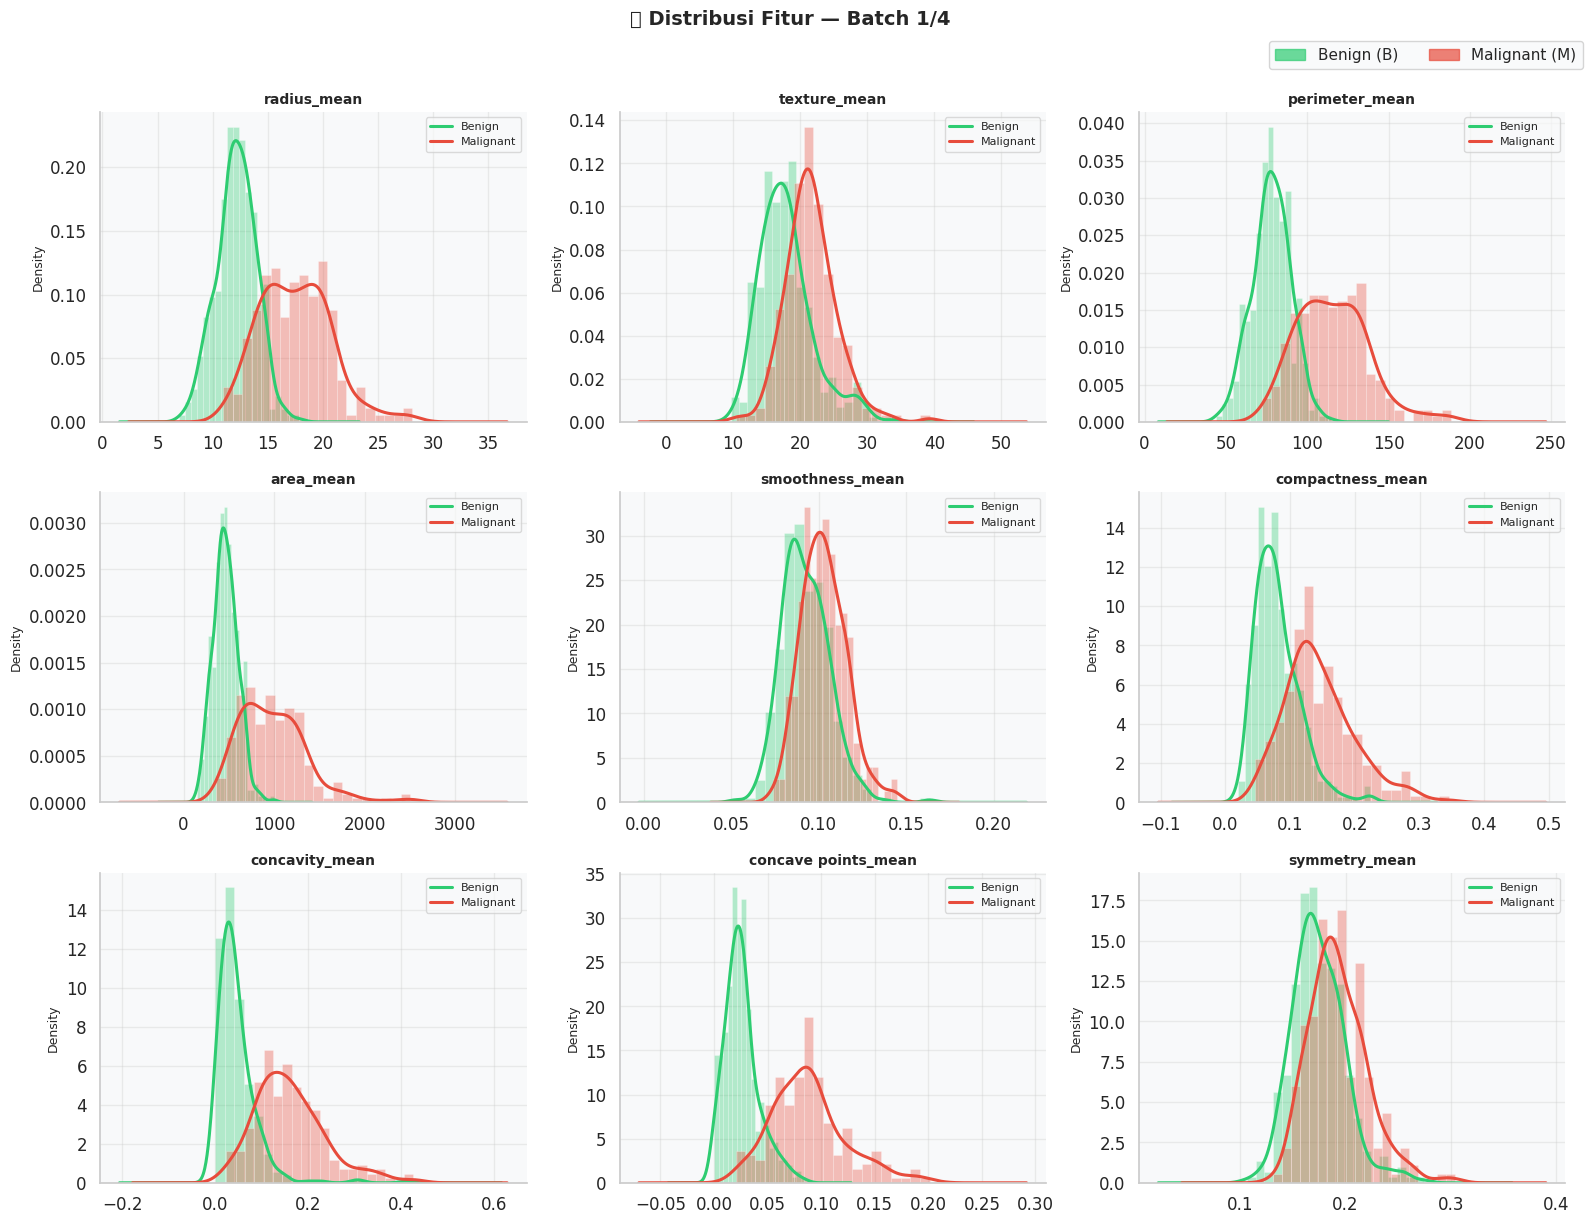

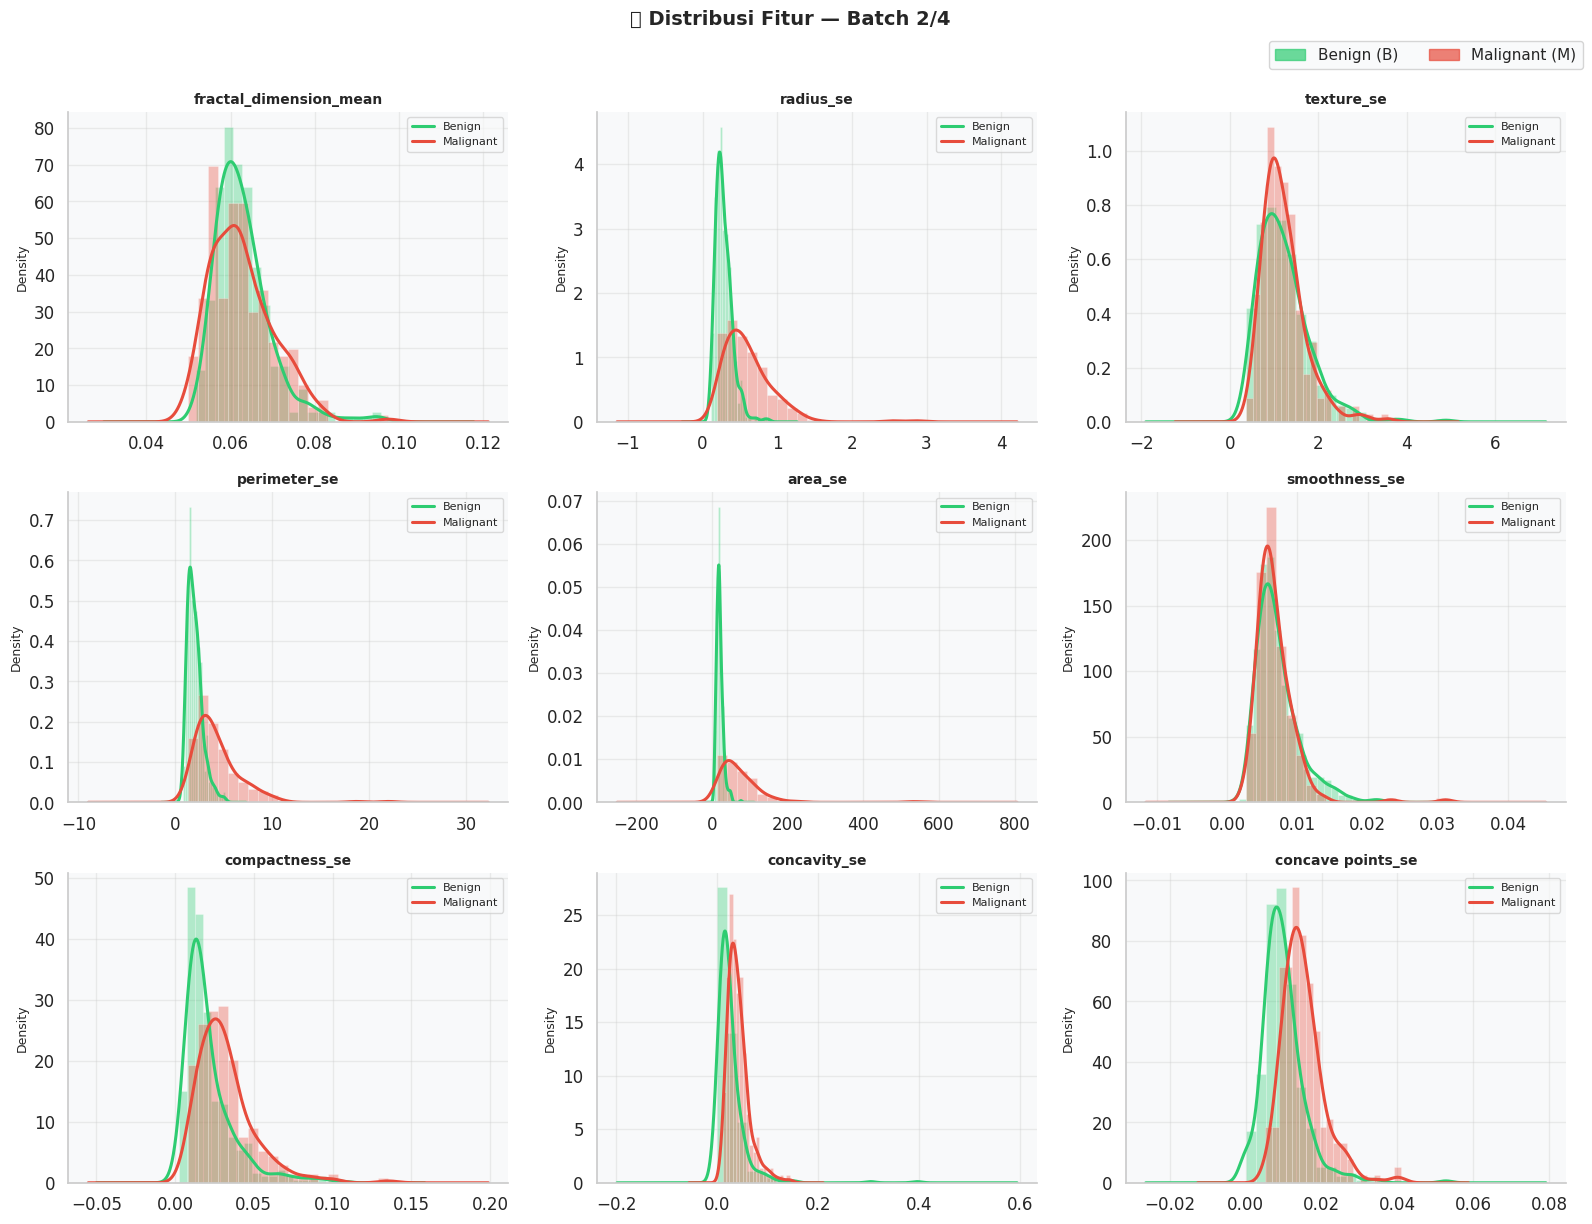

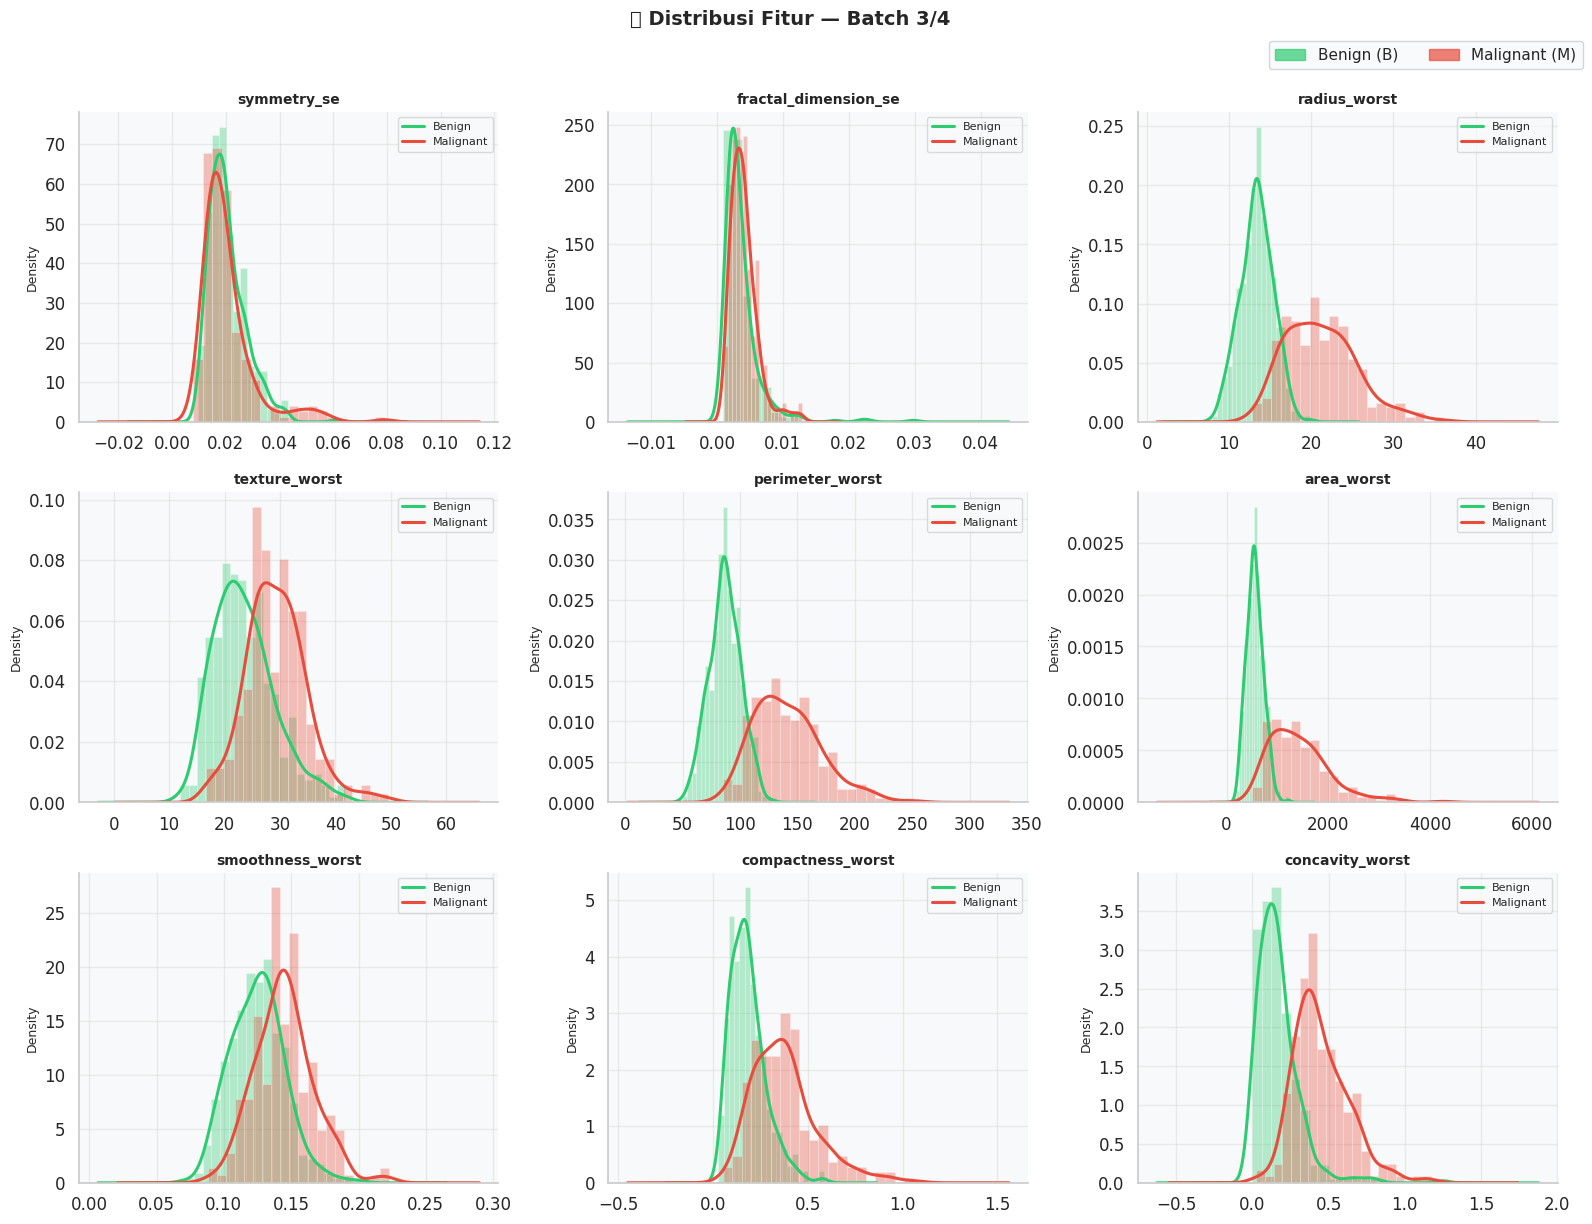

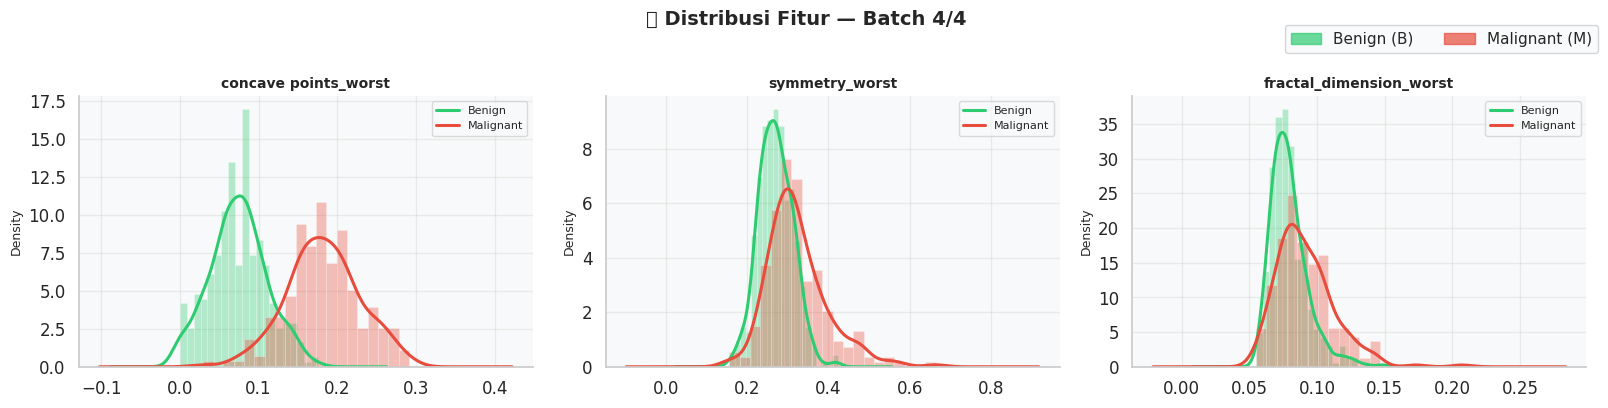

✅ Visualisasi histogram selesai.


In [60]:
feature_cols = [c for c in df.columns if c != TARGET_COL]
n_features   = len(feature_cols)
batch_size   = 9  # 3×3 grid
n_batches    = math.ceil(n_features / batch_size)

print(f"📊 Visualisasi {n_features} fitur dalam {n_batches} batch (grid 3×3)...")

for batch_i in range(n_batches):
    batch_feats = feature_cols[batch_i * batch_size : (batch_i + 1) * batch_size]
    n_this = len(batch_feats)
    n_rows = math.ceil(n_this / 3)

    fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_this == 1 else list(axes)
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()

    for j, feat in enumerate(batch_feats):
        ax = axes[j]
        for cls, col in zip(['B', 'M'], COLORS):
            subset = df[df[TARGET_COL] == cls][feat]
            ax.hist(subset, bins=20, density=True, alpha=0.35, color=col,
                    edgecolor='white', linewidth=0.5)
            subset.plot.kde(ax=ax, color=col, linewidth=2.2,
                            label=f"{'Benign' if cls=='B' else 'Malignant'}")
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Density', fontsize=9)
        ax.legend(fontsize=8, framealpha=0.7)

    # Hapus axes kosong
    for k in range(n_this, len(axes)):
        fig.delaxes(axes[k])

    # Patch legend manual di top
    patches = [
        mpatches.Patch(color=COLORS[0], alpha=0.7, label='Benign (B)'),
        mpatches.Patch(color=COLORS[1], alpha=0.7, label='Malignant (M)')
    ]
    fig.legend(handles=patches, loc='upper right', ncol=2, fontsize=11,
               framealpha=0.8, bbox_to_anchor=(1.0, 1.0))

    fig.suptitle(f"📊 Distribusi Fitur — Batch {batch_i+1}/{n_batches}",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("✅ Visualisasi histogram selesai.")

## 📦 SECTION 5: EDA — Box Plots per Fitur (by Class)

📦 Box Plot untuk 30 fitur, batch 9 per halaman...


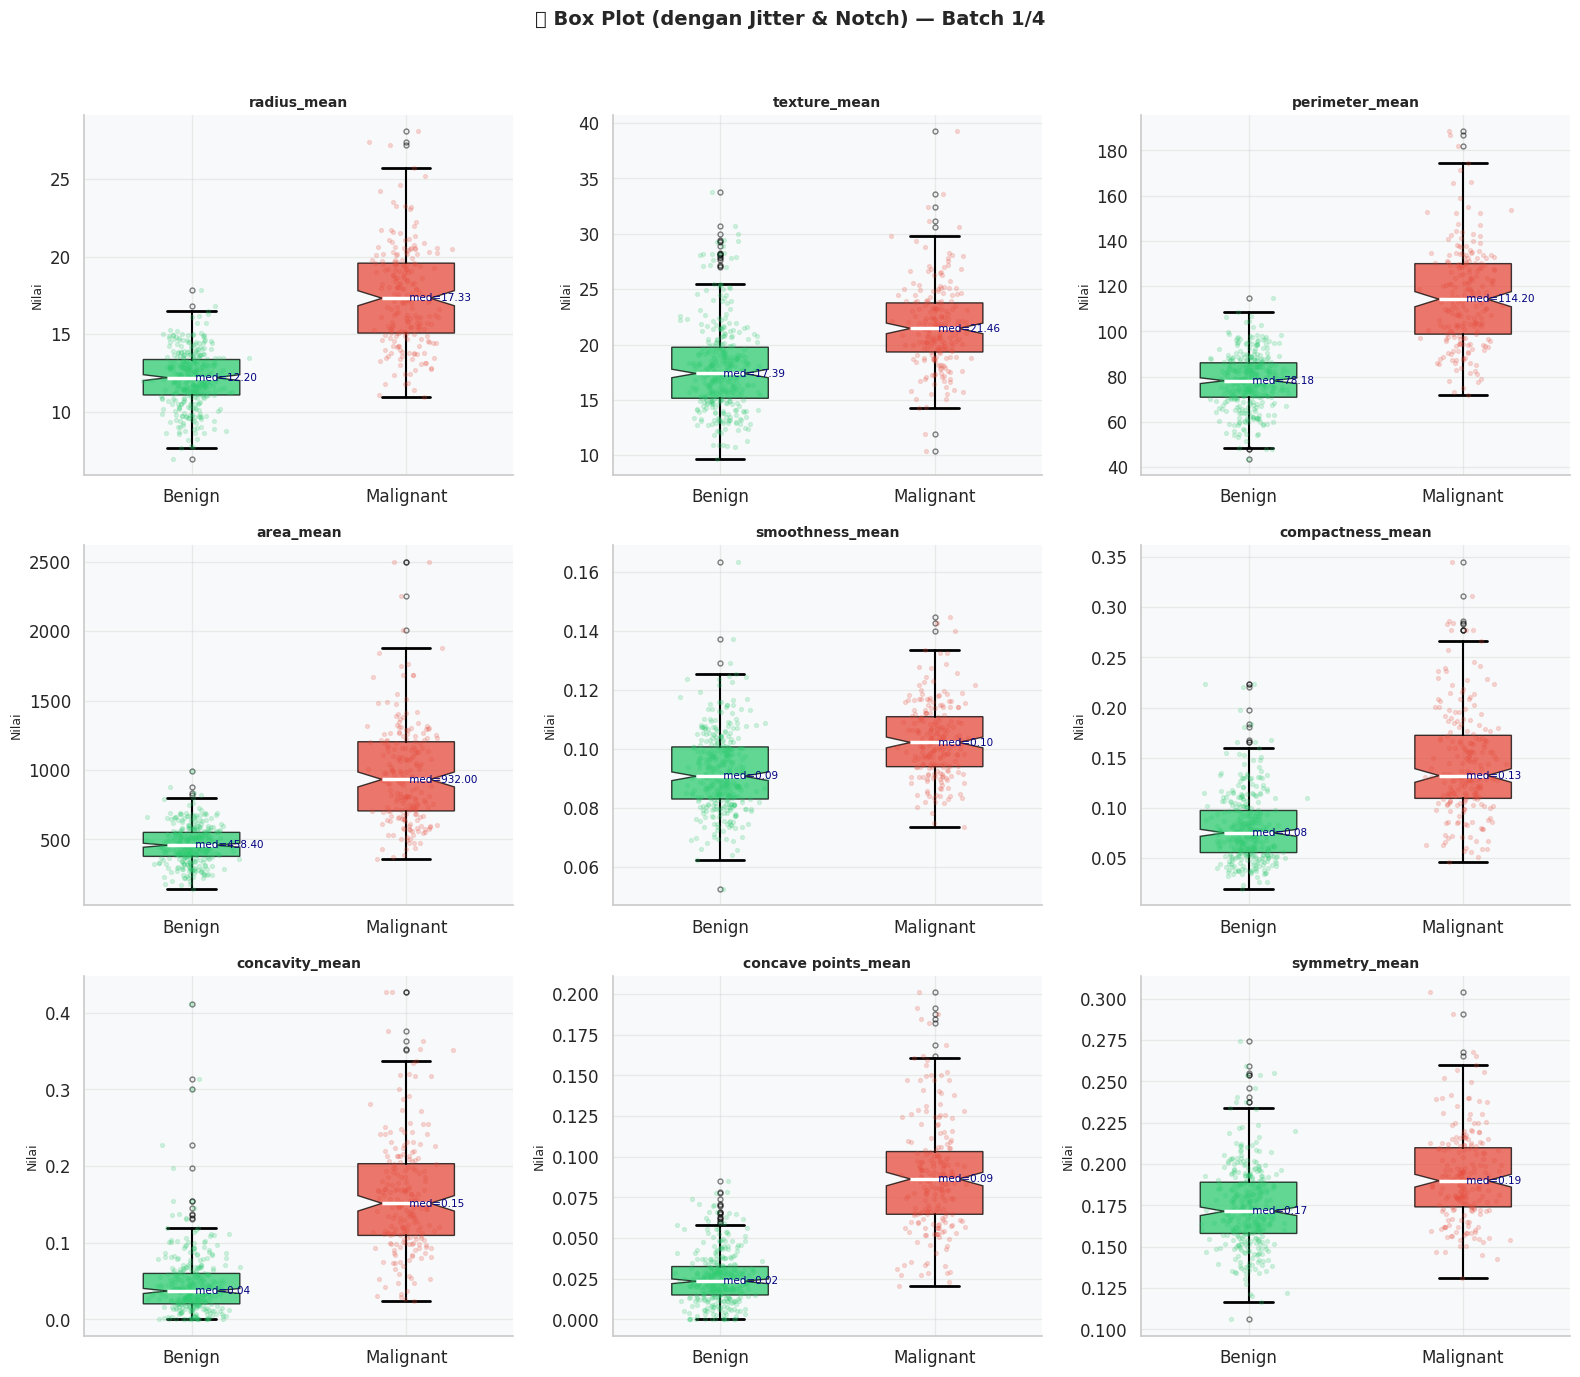

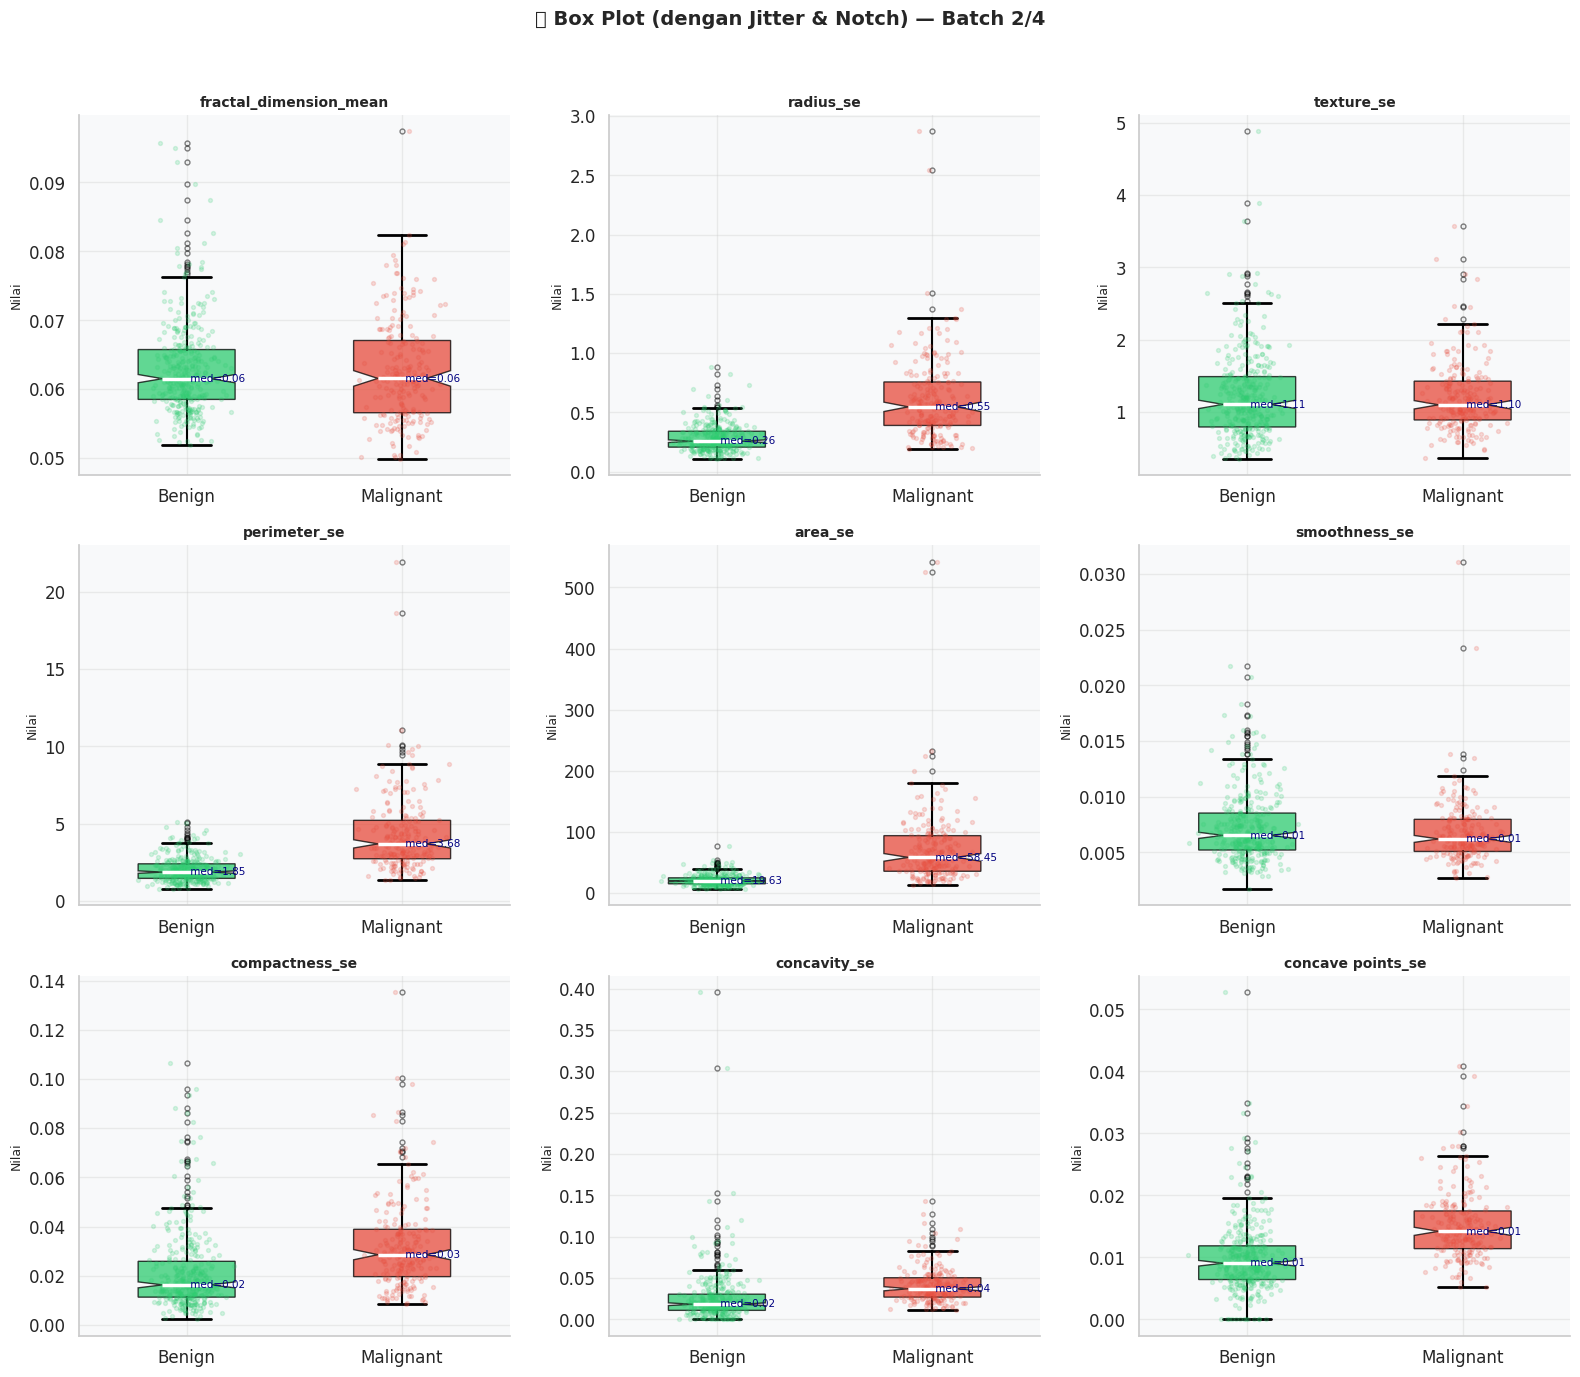

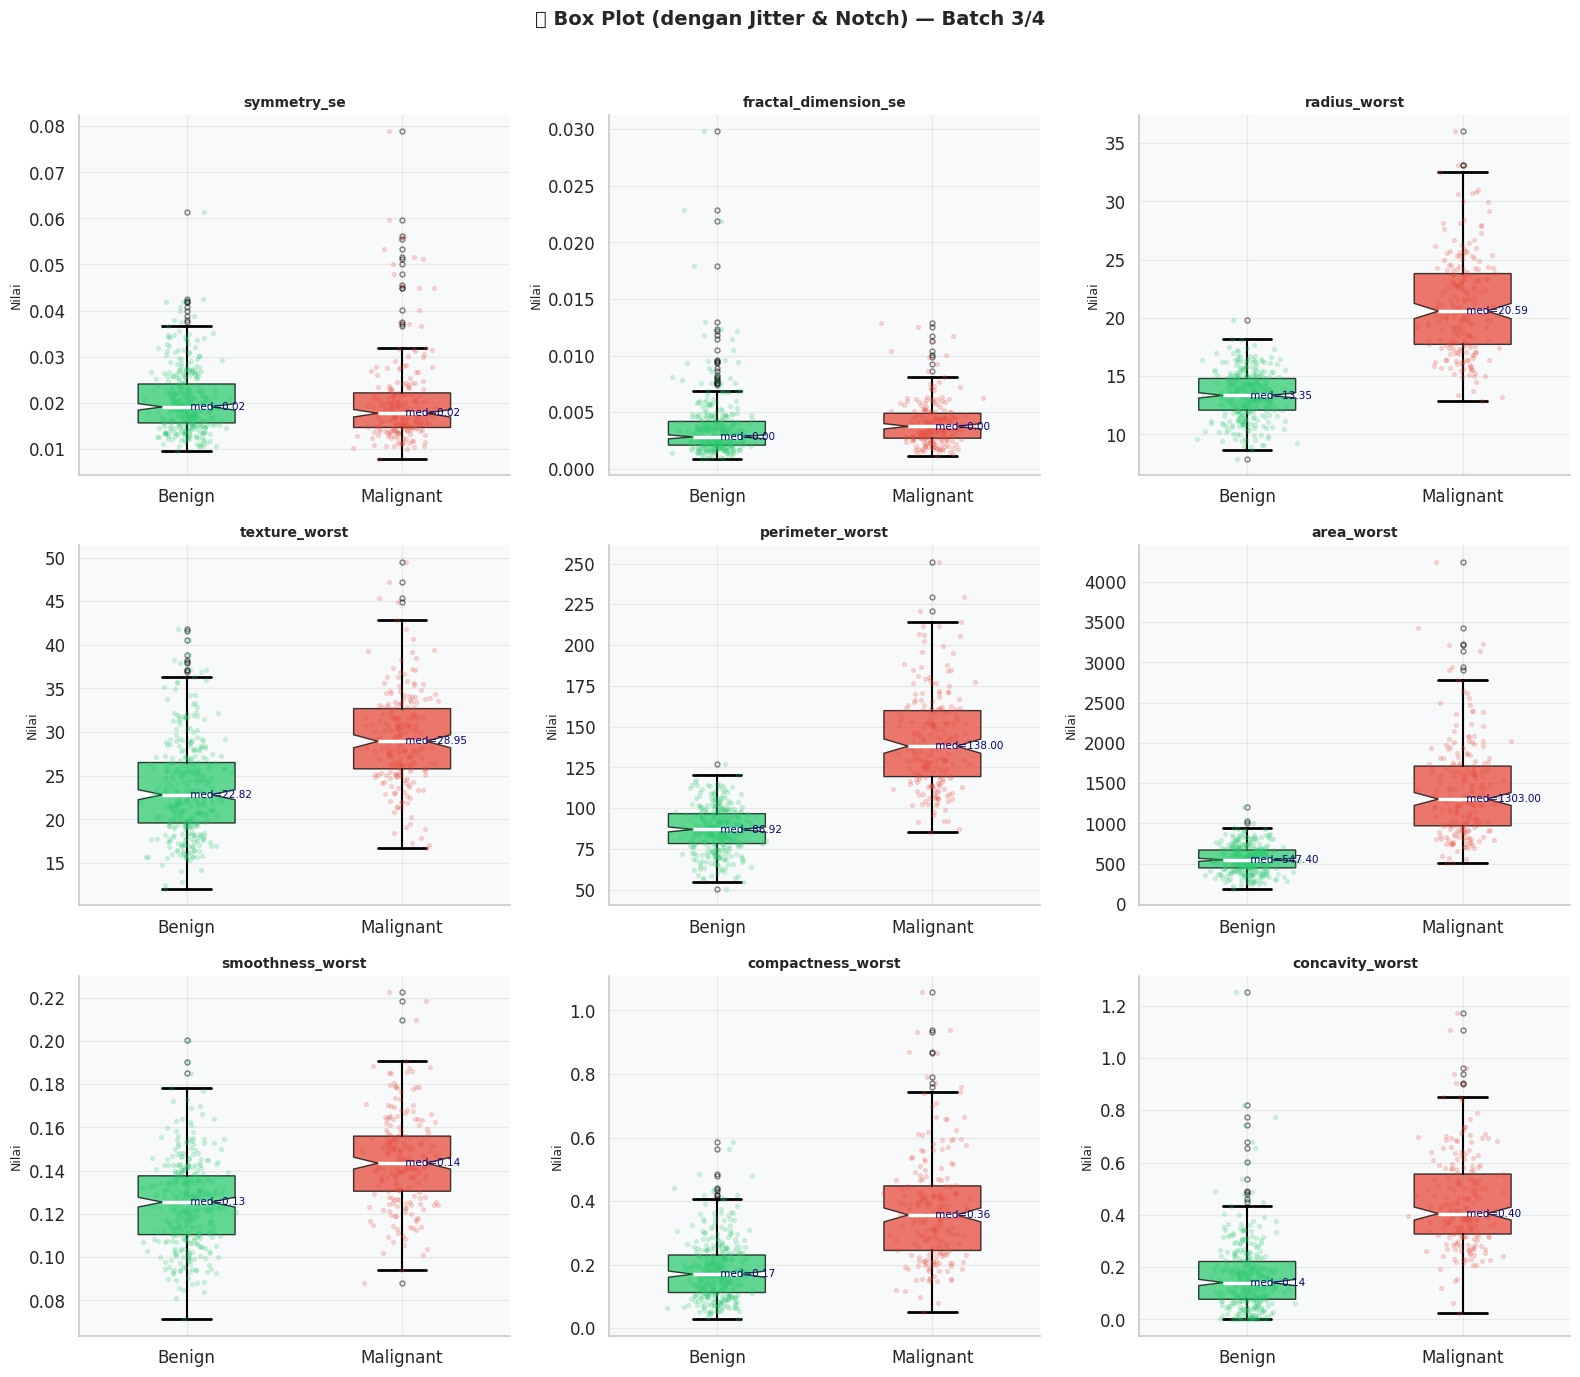

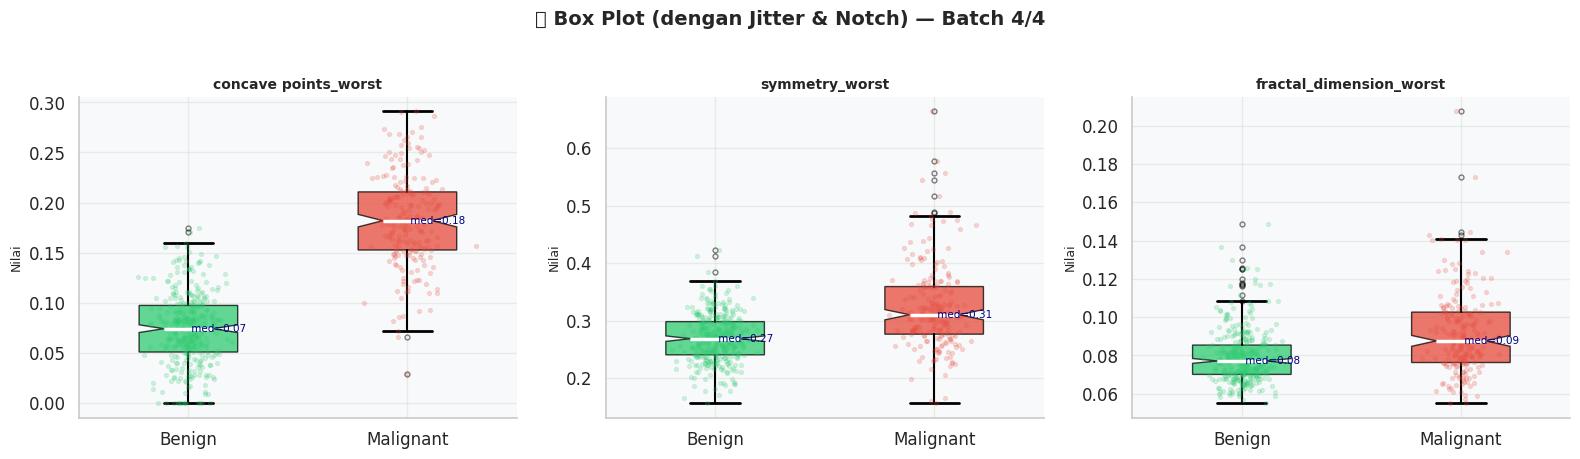

✅ Box plot selesai.


In [61]:
print(f"📦 Box Plot untuk {n_features} fitur, batch 9 per halaman...")

for batch_i in range(n_batches):
    batch_feats = feature_cols[batch_i * batch_size : (batch_i + 1) * batch_size]
    n_this = len(batch_feats)
    n_rows = math.ceil(n_this / 3)

    fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 4.5))
    if n_this == 1:
        axes = [axes]
    axes = np.array(axes).flatten()

    for j, feat in enumerate(batch_feats):
        ax = axes[j]
        data_B = df[df[TARGET_COL] == 'B'][feat]
        data_M = df[df[TARGET_COL] == 'M'][feat]

        bp = ax.boxplot(
            [data_B, data_M],
            labels=['Benign', 'Malignant'],
            patch_artist=True,
            notch=True,
            vert=True,
            widths=0.45,
            medianprops=dict(color='white', linewidth=2.5),
            flierprops=dict(marker='o', markersize=3.5, alpha=0.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=2)
        )
        for patch, color in zip(bp['boxes'], COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)

        # Overlay jitter
        for xi, (subset, color) in enumerate([(data_B, COLORS[0]), (data_M, COLORS[1])], 1):
            jitter = np.random.normal(xi, 0.07, size=len(subset))
            ax.scatter(jitter, subset, alpha=0.18, s=8, color=color, zorder=2)

        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_ylabel('Nilai', fontsize=9)

        # Annotate median values
        for xi, subset in enumerate([data_B, data_M], 1):
            ax.text(xi, subset.median(), f' med={subset.median():.2f}',
                    ha='left', va='center', fontsize=7.5, color='navy')

    for k in range(n_this, len(axes)):
        fig.delaxes(axes[k])

    fig.suptitle(f"📦 Box Plot (dengan Jitter & Notch) — Batch {batch_i+1}/{n_batches}",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("✅ Box plot selesai.")

## 🎻 SECTION 6: EDA — Violin Plots per Fitur (by Class)

🎻 Violin Plot untuk 30 fitur, batch 9 per halaman...


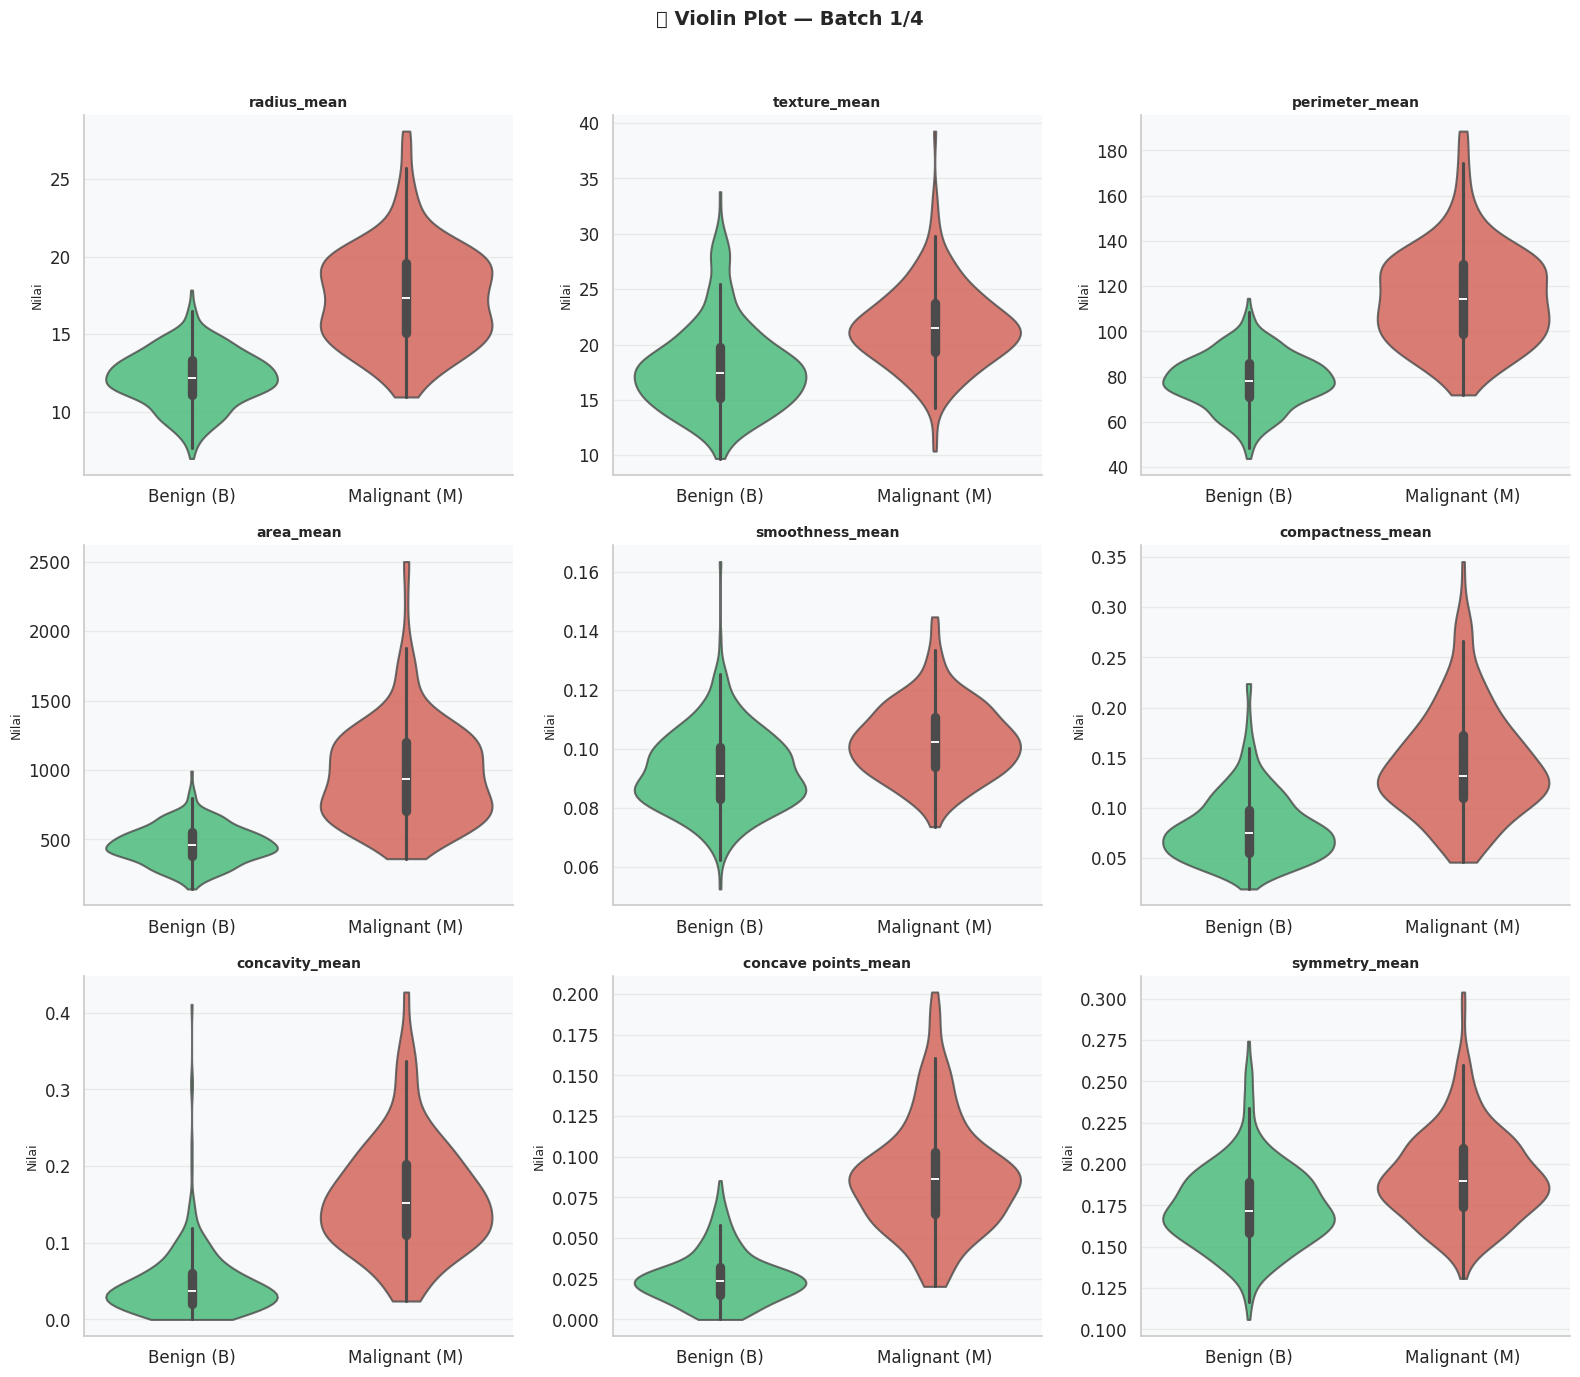

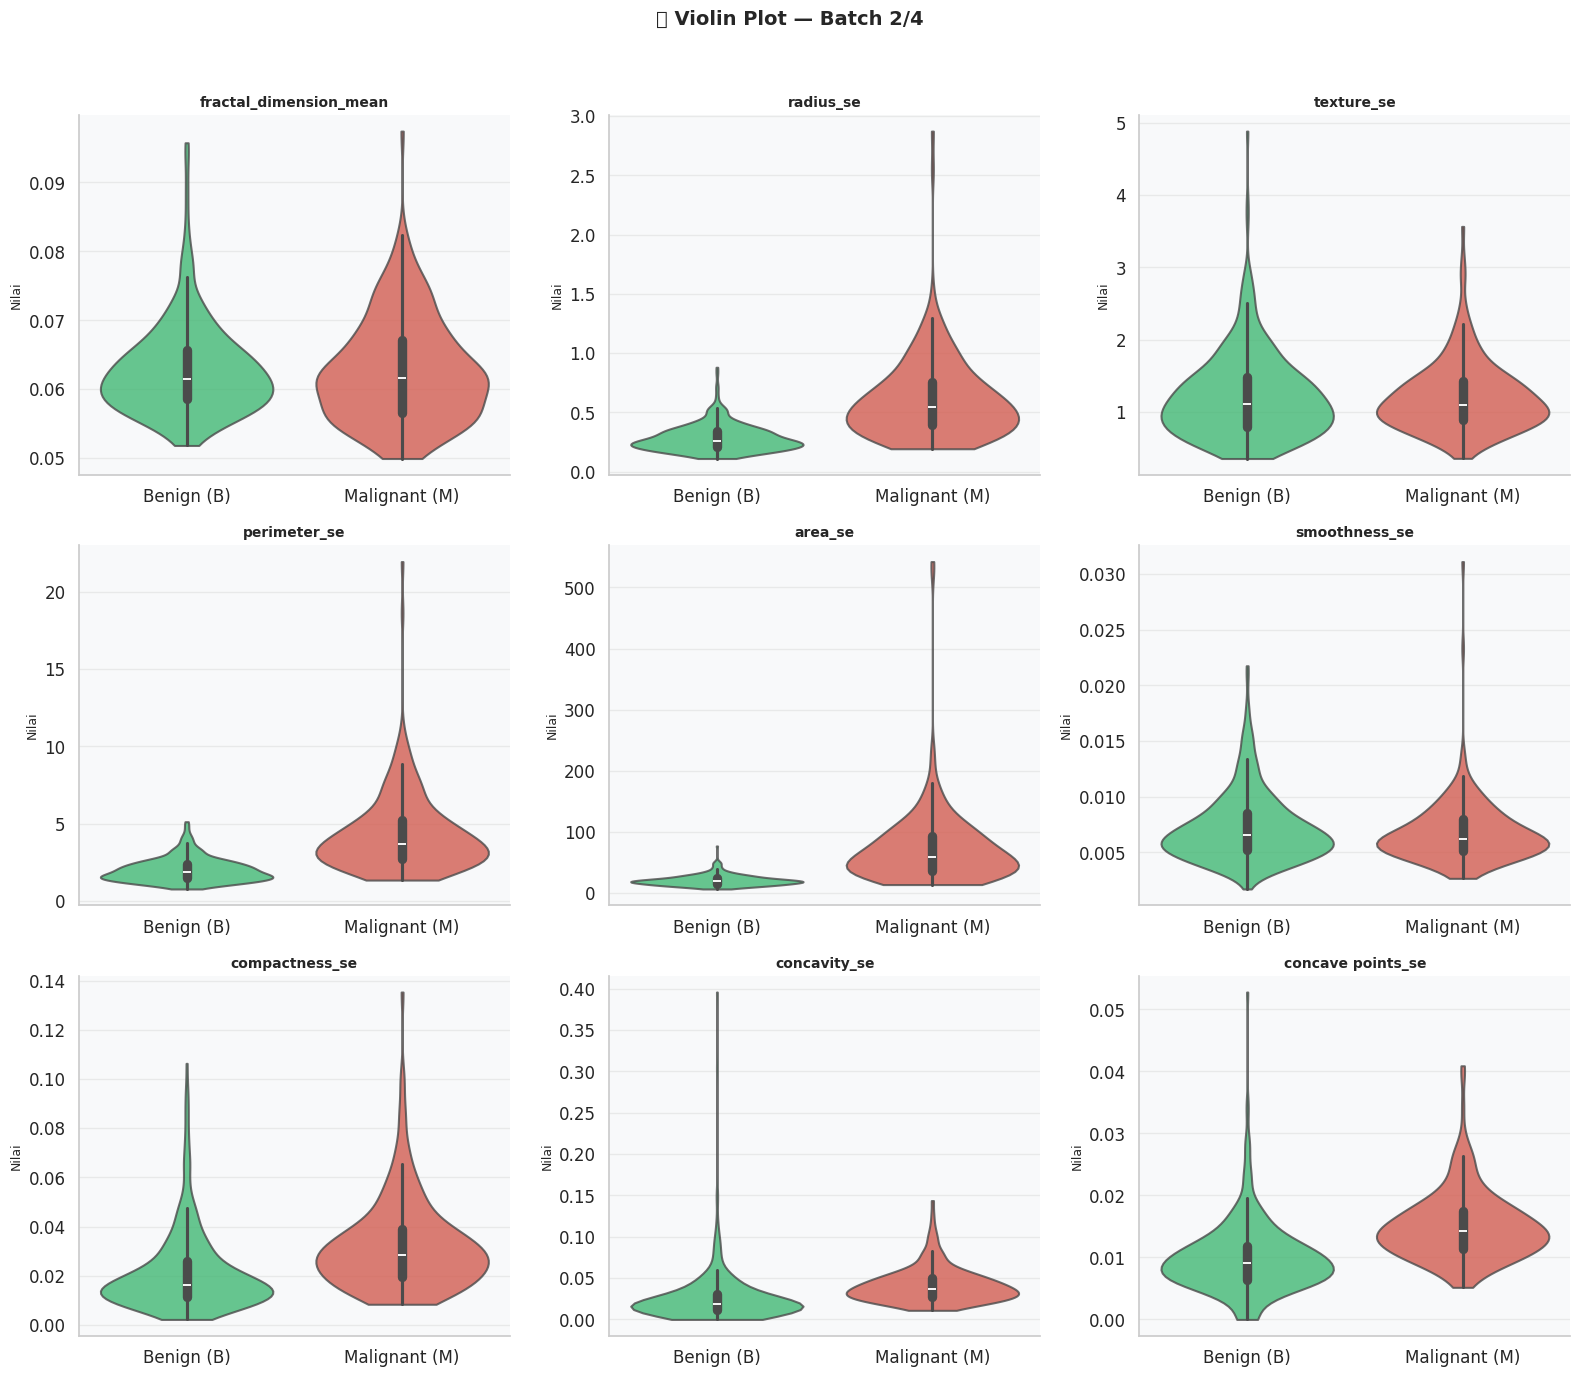

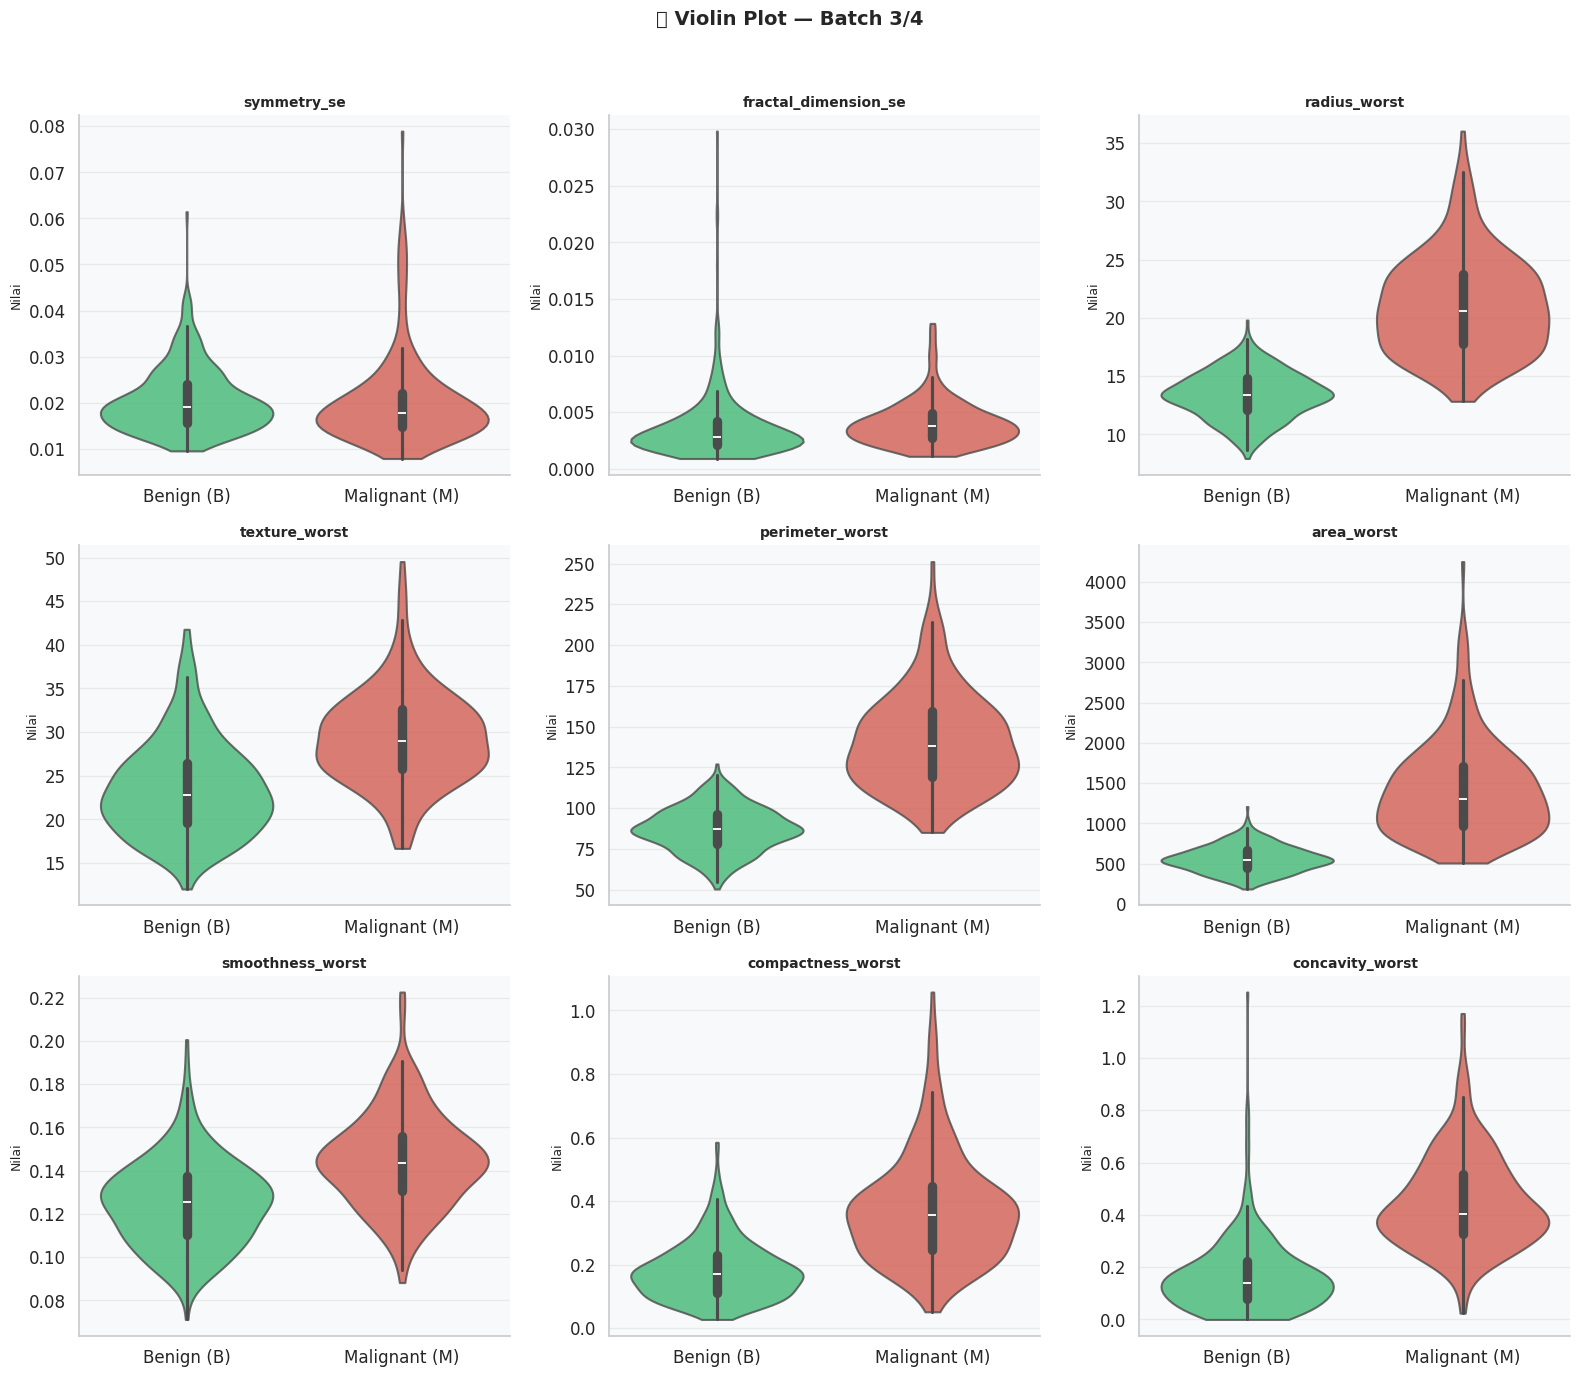

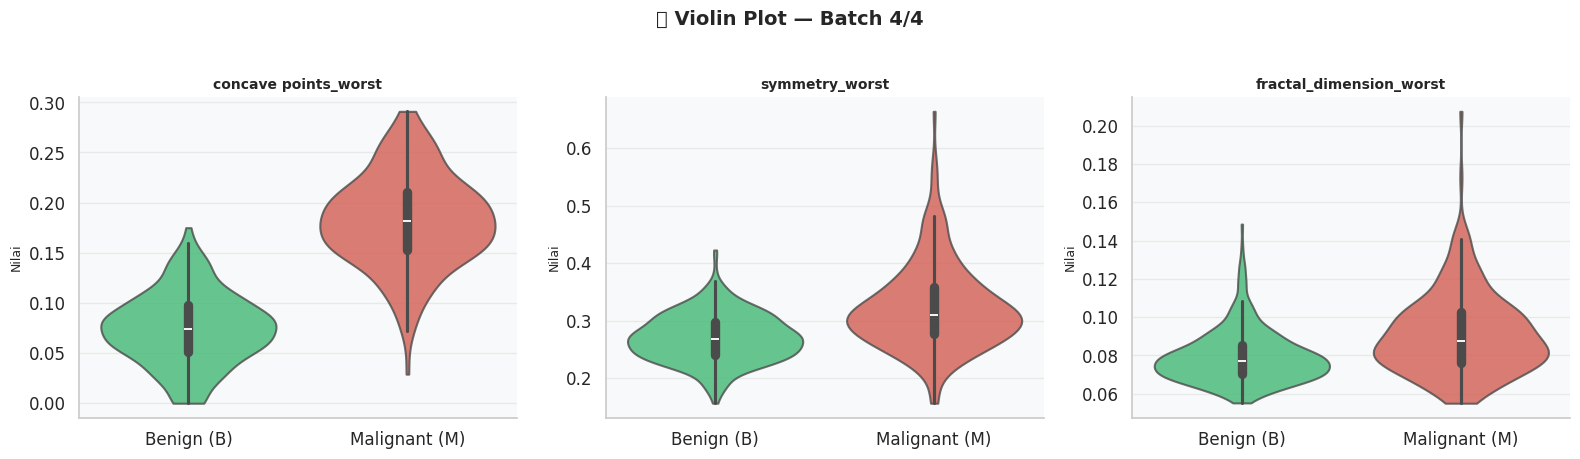

✅ Violin plot selesai.


In [62]:
print(f"🎻 Violin Plot untuk {n_features} fitur, batch 9 per halaman...")

for batch_i in range(n_batches):
    batch_feats = feature_cols[batch_i * batch_size : (batch_i + 1) * batch_size]
    n_this = len(batch_feats)
    n_rows = math.ceil(n_this / 3)

    fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 4.5))
    if n_this == 1:
        axes = [axes]
    axes = np.array(axes).flatten()

    for j, feat in enumerate(batch_feats):
        ax = axes[j]
        plot_df = df[[TARGET_COL, feat]].copy()
        sns.violinplot(
            data=plot_df, x=TARGET_COL, y=feat,
            palette={'B': COLORS[0], 'M': COLORS[1]},
            inner='box', cut=0, linewidth=1.5, ax=ax, alpha=0.8,
            order=['B', 'M']
        )
        ax.set_xticklabels(['Benign (B)', 'Malignant (M)'])
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Nilai', fontsize=9)

    for k in range(n_this, len(axes)):
        fig.delaxes(axes[k])

    fig.suptitle(f"🎻 Violin Plot — Batch {batch_i+1}/{n_batches}",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("✅ Violin plot selesai.")

## 🚨 SECTION 7: EDA — Deteksi Outlier (IQR Method)

🚨  DETEKSI OUTLIER (IQR Method)

Top-10 Fitur dengan Outlier Terbanyak:


,Feature,N_Outlier,Pct (%),Lower,Upper
13,area_se,65,11.42%,-23.160000,86.200000
10,radius_se,38,6.68%,-0.137400,0.848600
12,perimeter_se,38,6.68%,-1.020500,5.983500
23,area_worst,35,6.15%,-337.750000,1937.050000
14,smoothness_se,30,5.27%,0.000700,0.012600
19,fractal_dimension_se,28,4.92%,-0.001200,0.008000
15,compactness_se,28,4.92%,-0.016000,0.061500
18,symmetry_se,27,4.75%,0.002700,0.036000
3,area_mean,25,4.39%,-123.300000,1326.300000
29,fractal_dimension_worst,24,4.22%,0.040500,0.123000


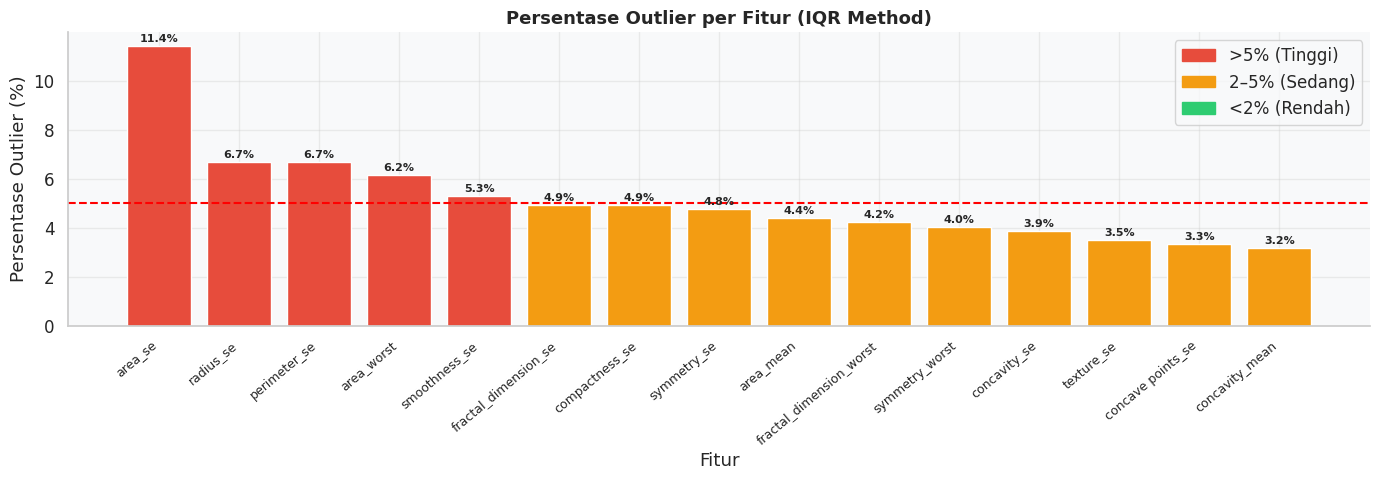

✅ Analisis outlier selesai.


In [63]:
print("=" * 60)
print("🚨  DETEKSI OUTLIER (IQR Method)")
print("=" * 60)

outlier_summary = []
for feat in feature_cols:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[feat] < lower) | (df[feat] > upper)).sum()
    pct    = n_out / len(df) * 100
    outlier_summary.append({'Feature': feat, 'N_Outlier': n_out,
                             'Pct (%)': round(pct, 2),
                             'Lower': round(lower, 4), 'Upper': round(upper, 4)})

out_df = pd.DataFrame(outlier_summary).sort_values('N_Outlier', ascending=False)
print("\nTop-10 Fitur dengan Outlier Terbanyak:")
display(out_df.head(10).style
    .background_gradient(cmap='Reds', subset=['N_Outlier', 'Pct (%)'])
    .format({'Pct (%)': '{:.2f}%'})
)

# Visualisasi Bar Chart Outlier
top_out = out_df.head(15)
fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = ['#e74c3c' if p > 5 else '#f39c12' if p > 2 else '#2ecc71'
              for p in top_out['Pct (%)']]
bars = ax.bar(top_out['Feature'], top_out['Pct (%)'], color=colors_bar,
              edgecolor='white', linewidth=1)
for bar, val in zip(bars, top_out['Pct (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(5, color='red', linestyle='--', linewidth=1.5, label='Threshold 5%')
ax.set_title('Persentase Outlier per Fitur (IQR Method)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fitur')
ax.set_ylabel('Persentase Outlier (%)')
ax.set_xticklabels(top_out['Feature'], rotation=40, ha='right', fontsize=9)
ax.legend()
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='>5% (Tinggi)'),
    mpatches.Patch(color='#f39c12', label='2–5% (Sedang)'),
    mpatches.Patch(color='#2ecc71', label='<2% (Rendah)')
]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Analisis outlier selesai.")

## 🌡️ SECTION 8: Korelasi — Full Heatmap (Semua Fitur)

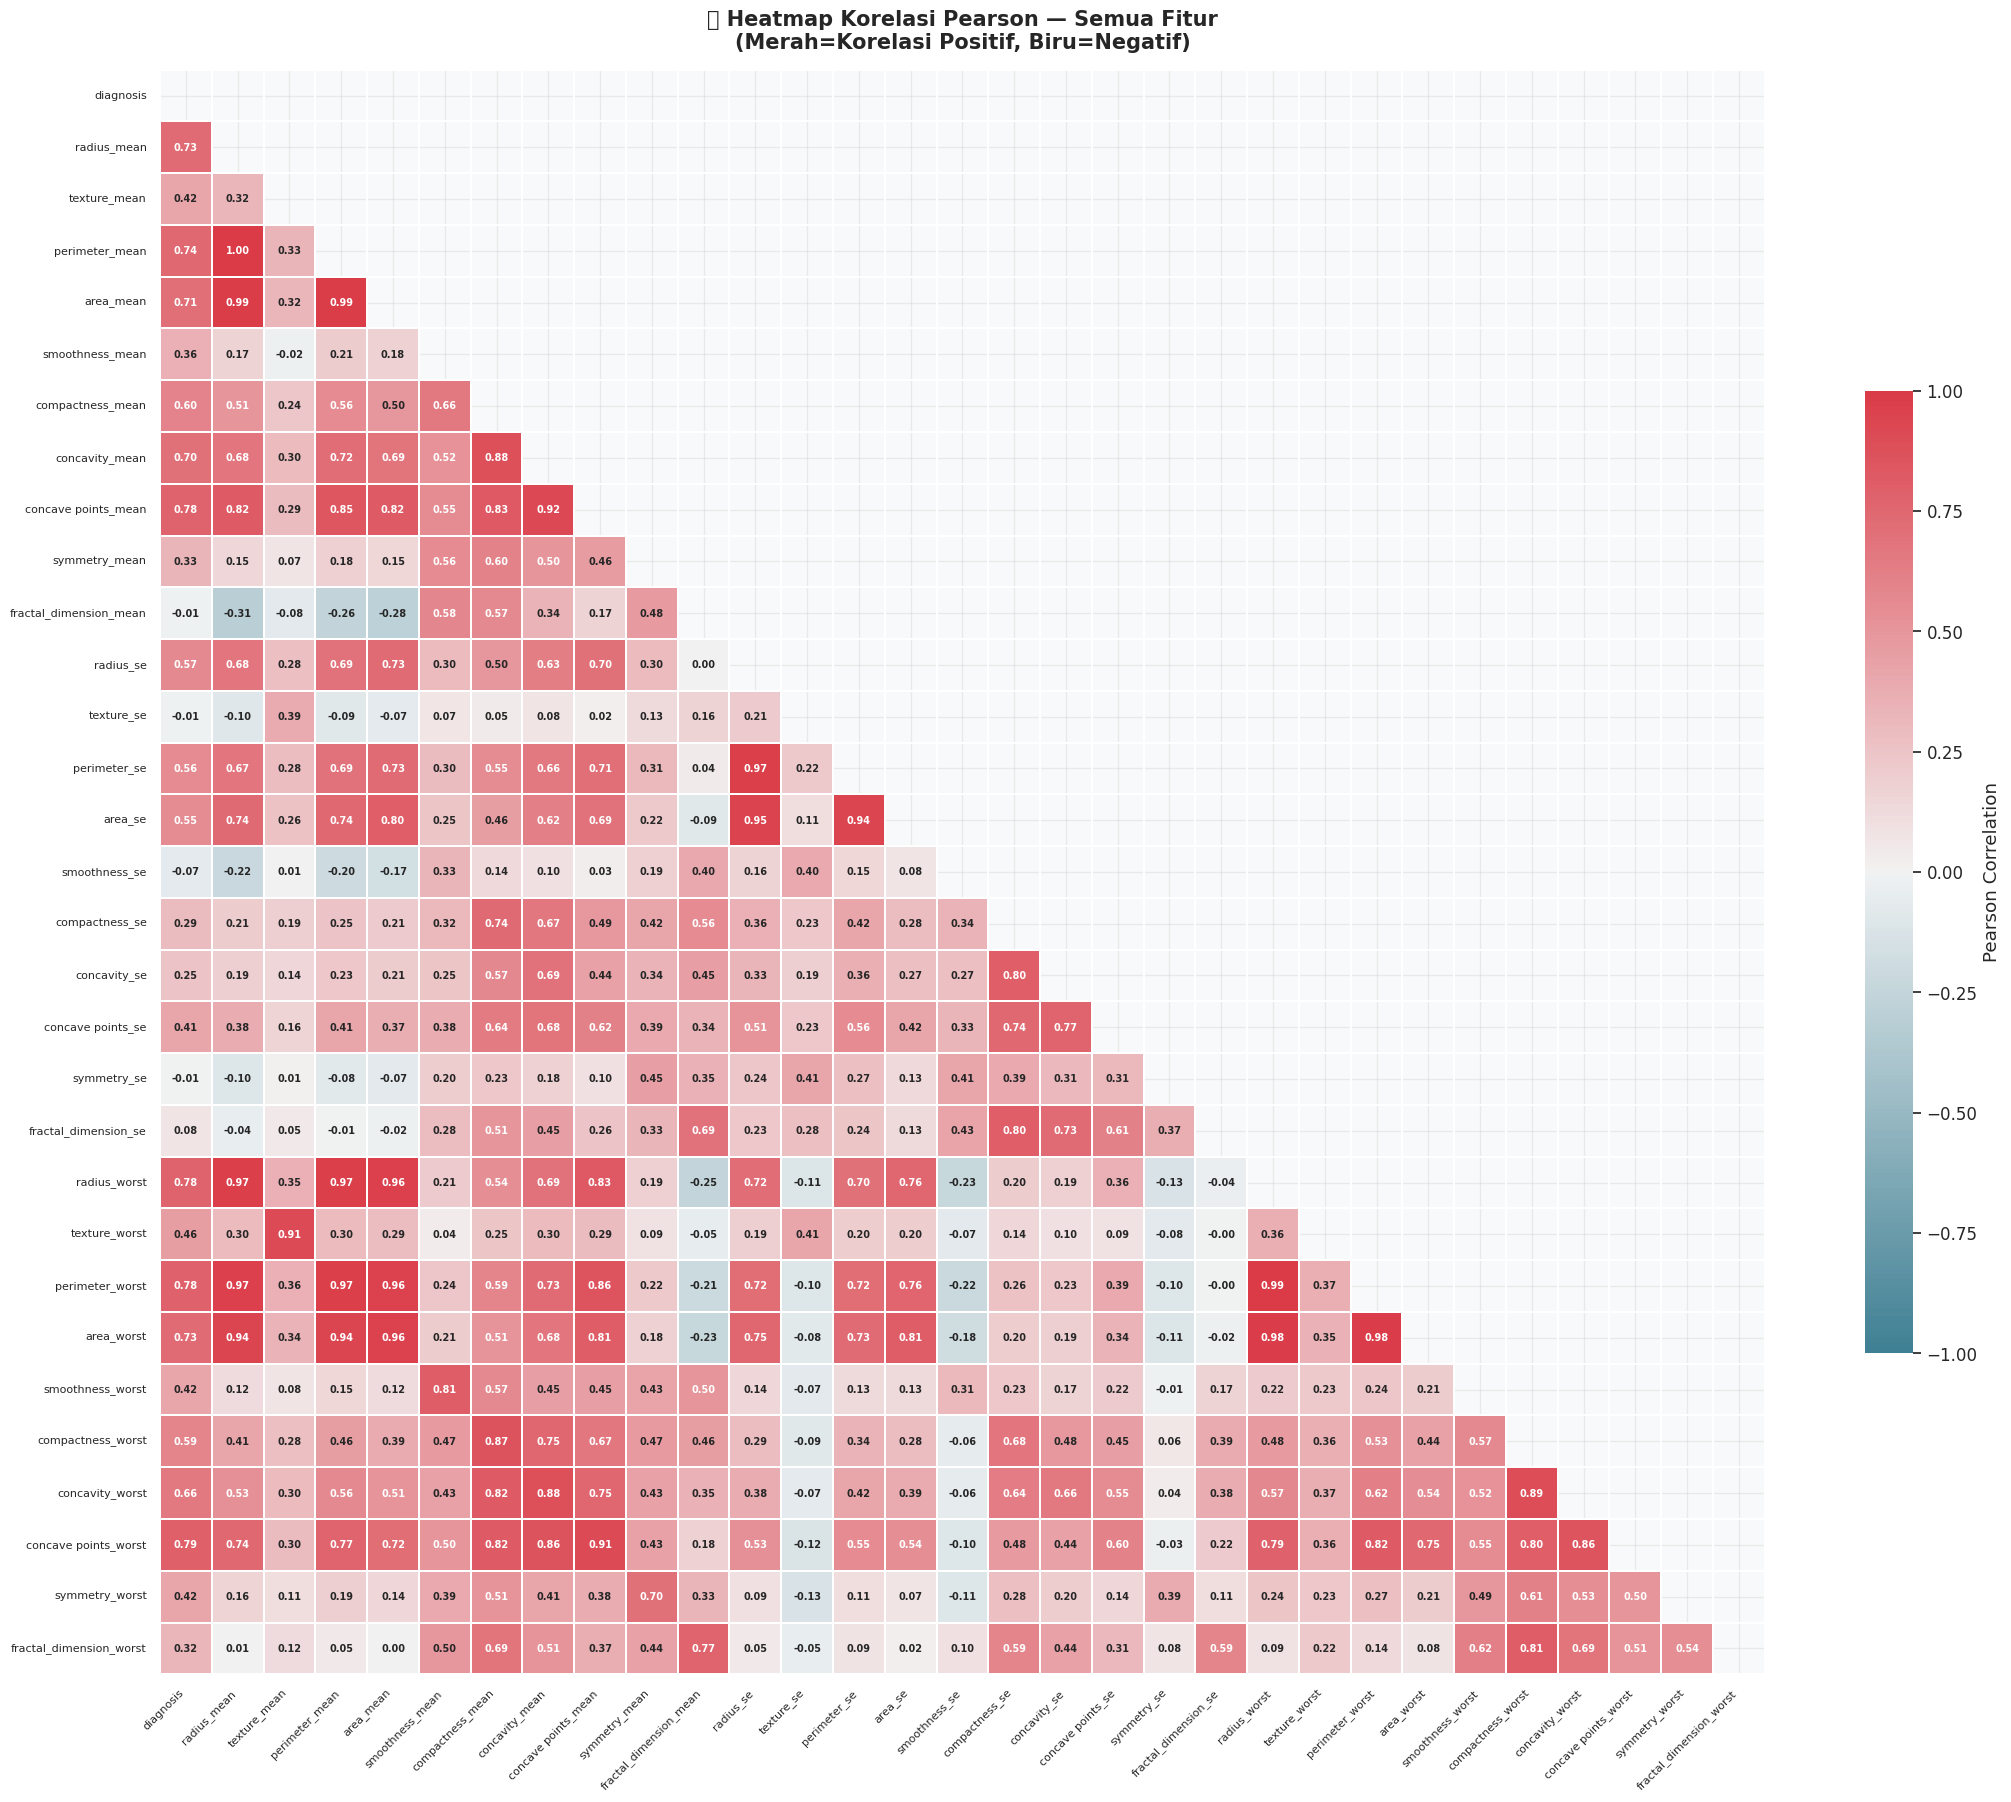

✅ Full correlation heatmap selesai.


In [64]:
# Encode target untuk kalkulasi korelasi
le = LabelEncoder()
df_enc = df.copy()
df_enc[TARGET_COL] = le.fit_transform(df[TARGET_COL])  # B=0, M=1

corr_all = df_enc.corr(method='pearson')
abs_corr  = corr_all.abs()

mask = np.zeros_like(abs_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corr_all, mask=mask, cmap=cmap,
    vmin=-1, vmax=1, center=0,
    square=True, annot=True, fmt='.2f',
    annot_kws={'size': 7, 'weight': 'bold'},
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.6},
    ax=ax
)
ax.set_title('🌡️ Heatmap Korelasi Pearson — Semua Fitur\n(Merah=Korelasi Positif, Biru=Negatif)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()
print("✅ Full correlation heatmap selesai.")

## 🏆 SECTION 9: Ranking Korelasi terhadap Target + Eliminasi Multikolinearitas

🏆 RANKING KORELASI TERHADAP DIAGNOSIS (absolut):
---------------------------------------------
   1. concave points_worst           0.7936  ███████████████
   2. perimeter_worst                0.7829  ███████████████
   3. concave points_mean            0.7766  ███████████████
   4. radius_worst                   0.7765  ███████████████
   5. perimeter_mean                 0.7426  ██████████████
   6. area_worst                     0.7338  ██████████████
   7. radius_mean                    0.7300  ██████████████
   8. area_mean                      0.7090  ██████████████
   9. concavity_mean                 0.6964  █████████████
  10. concavity_worst                0.6596  █████████████
  11. compactness_mean               0.5965  ███████████
  12. compactness_worst              0.5910  ███████████
  13. radius_se                      0.5671  ███████████
  14. perimeter_se                   0.5561  ███████████
  15. area_se                        0.5482  ██████████
  16. texture_worst

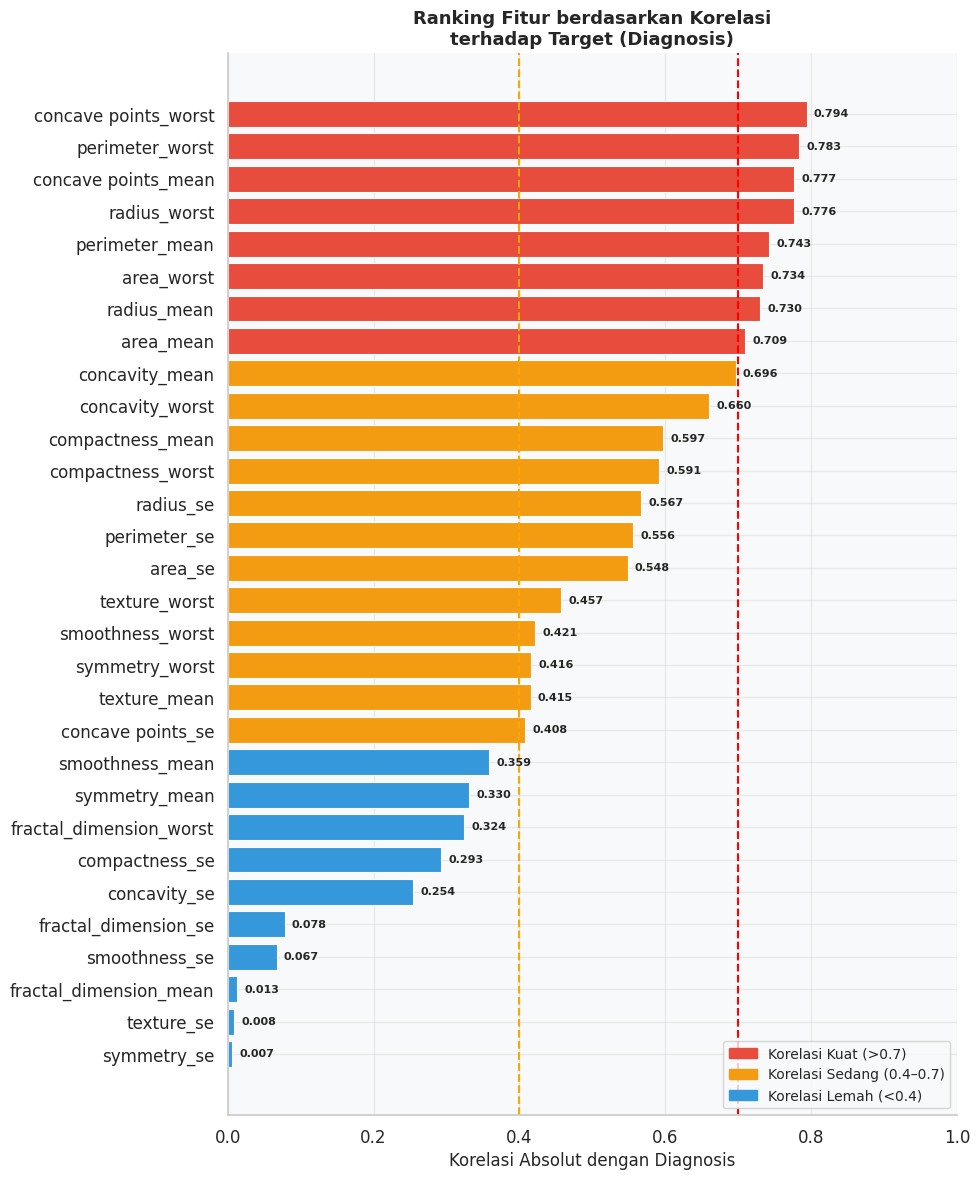

In [65]:
# ── Ranking korelasi terhadap target ─────────────────────
target_corr_series = abs_corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

print("🏆 RANKING KORELASI TERHADAP DIAGNOSIS (absolut):")
print("-" * 45)
for rank, (feat, val) in enumerate(target_corr_series.items(), 1):
    bar_vis = '█' * int(val * 20)
    print(f"  {rank:2d}. {feat:<30} {val:.4f}  {bar_vis}")

# Visualisasi ranking
fig, ax = plt.subplots(figsize=(10, 12))
colors_rank = ['#e74c3c' if v > 0.7 else '#f39c12' if v > 0.4 else '#3498db'
               for v in target_corr_series]
ax.barh(target_corr_series.index[::-1], target_corr_series.values[::-1],
        color=colors_rank[::-1], edgecolor='white', linewidth=0.8)
ax.axvline(0.4, color='orange', linestyle='--', linewidth=1.5, label='Threshold 0.4 (Sedang)')
ax.axvline(0.7, color='red',    linestyle='--', linewidth=1.5, label='Threshold 0.7 (Kuat)')
ax.set_xlabel('Korelasi Absolut dengan Diagnosis', fontsize=12)
ax.set_title('Ranking Fitur berdasarkan Korelasi\nterhadap Target (Diagnosis)',
             fontsize=13, fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Korelasi Kuat (>0.7)'),
    mpatches.Patch(color='#f39c12', label='Korelasi Sedang (0.4–0.7)'),
    mpatches.Patch(color='#3498db', label='Korelasi Lemah (<0.4)')
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)
ax.set_xlim(0, 1.0)
for i, (feat, val) in enumerate(zip(target_corr_series.index[::-1], target_corr_series.values[::-1])):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

In [66]:
# ════════════════════════════════════════════════════════════
#  ELIMINASI MULTIKOLINEARITAS (Threshold 0.8)
#  Metode: ambil fitur dengan korelasi-target lebih tinggi
# ════════════════════════════════════════════════════════════
MULTICOL_THRESHOLD = 0.8
sorted_feats = target_corr_series.index.tolist()
feats_to_drop = set()

print(f"🧹 ELIMINASI MULTIKOLINEARITAS (threshold > {MULTICOL_THRESHOLD})")
print("-" * 60)

for i in range(len(sorted_feats)):
    f1 = sorted_feats[i]
    if f1 in feats_to_drop:
        continue
    for j in range(i + 1, len(sorted_feats)):
        f2 = sorted_feats[j]
        if f2 in feats_to_drop:
            continue
        corr_val = abs(corr_all.loc[f1, f2])
        if corr_val > MULTICOL_THRESHOLD:
            feats_to_drop.add(f2)
            print(f"  ❌ Buang '{f2:<30}' (cor={corr_val:.2f} dengan '{f1}')")

selected_features = [f for f in sorted_feats if f not in feats_to_drop]

print("\n" + "=" * 60)
print(f"  Fitur awal          : {len(sorted_feats)}")
print(f"  Fitur dibuang       : {len(feats_to_drop)}")
print(f"  Fitur TERPILIH      : {len(selected_features)}")
print("=" * 60)
print("\n💎 Fitur Terpilih (bebas multikolinearitas):")
for rank, f in enumerate(selected_features, 1):
    print(f"  {rank:2d}. {f:<30} corr={target_corr_series[f]:.4f}")

🧹 ELIMINASI MULTIKOLINEARITAS (threshold > 0.8)
------------------------------------------------------------
  ❌ Buang 'perimeter_worst               ' (cor=0.82 dengan 'concave points_worst')
  ❌ Buang 'concave points_mean           ' (cor=0.91 dengan 'concave points_worst')
  ❌ Buang 'concavity_mean                ' (cor=0.86 dengan 'concave points_worst')
  ❌ Buang 'concavity_worst               ' (cor=0.86 dengan 'concave points_worst')
  ❌ Buang 'compactness_mean              ' (cor=0.82 dengan 'concave points_worst')
  ❌ Buang 'compactness_worst             ' (cor=0.80 dengan 'concave points_worst')
  ❌ Buang 'perimeter_mean                ' (cor=0.97 dengan 'radius_worst')
  ❌ Buang 'area_worst                    ' (cor=0.98 dengan 'radius_worst')
  ❌ Buang 'radius_mean                   ' (cor=0.97 dengan 'radius_worst')
  ❌ Buang 'area_mean                     ' (cor=0.96 dengan 'radius_worst')
  ❌ Buang 'perimeter_se                  ' (cor=0.97 dengan 'radius_se')
  ❌ Buang 

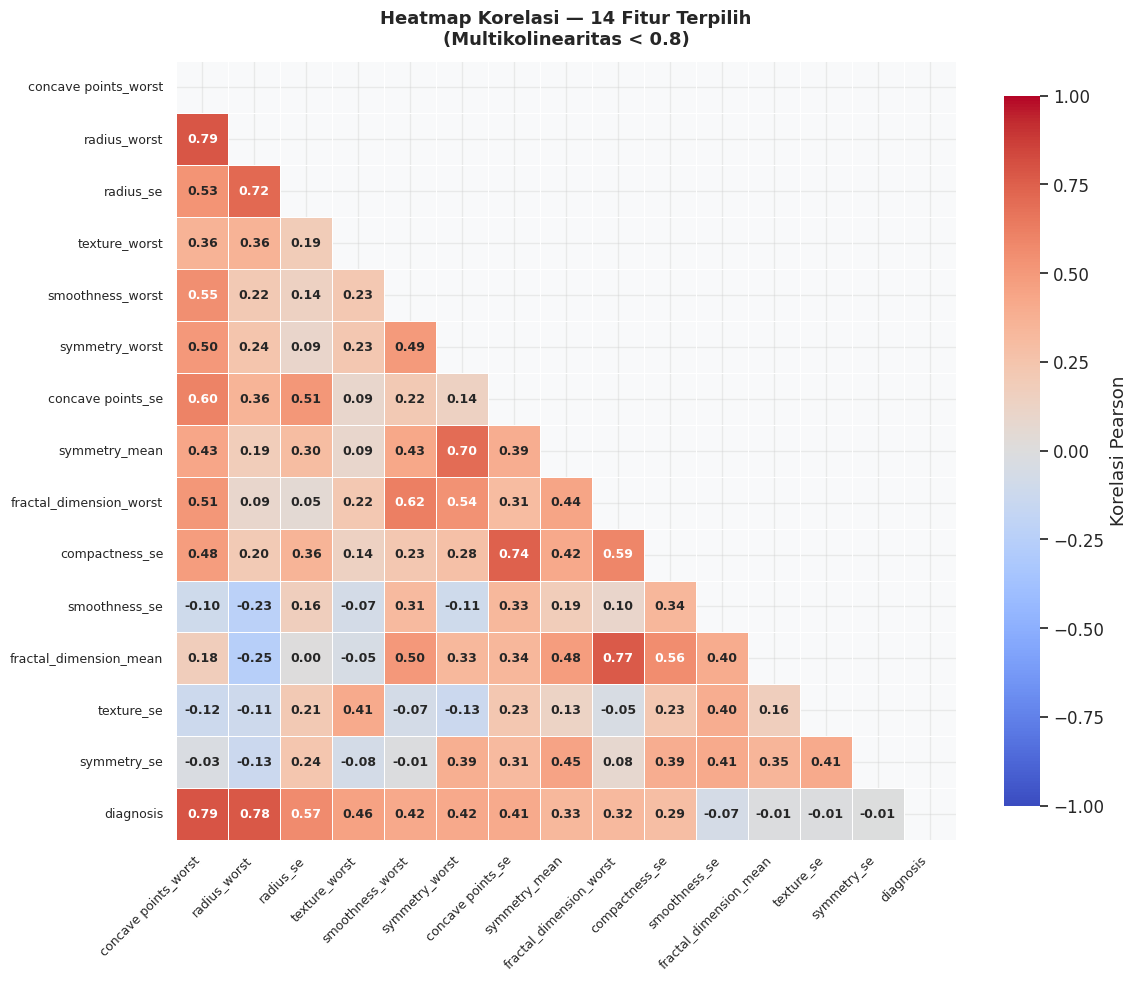

✅ Reduced heatmap selesai.


In [67]:
# Heatmap korelasi FITUR TERPILIH saja
df_selected_enc = df_enc[selected_features + [TARGET_COL]]
corr_selected   = df_selected_enc.corr(method='pearson')

mask_sel = np.zeros_like(corr_selected, dtype=bool)
mask_sel[np.triu_indices_from(mask_sel)] = True

fig, ax = plt.subplots(figsize=(max(10, len(selected_features)*0.7 + 2),
                                max(8, len(selected_features)*0.6 + 2)))
sns.heatmap(
    corr_selected, mask=mask_sel,
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    square=True, annot=True, fmt='.2f',
    annot_kws={'size': 9, 'weight': 'bold'},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Korelasi Pearson', 'shrink': 0.8},
    ax=ax
)
ax.set_title(f'Heatmap Korelasi — {len(selected_features)} Fitur Terpilih\n(Multikolinearitas < {MULTICOL_THRESHOLD})',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()
print("✅ Reduced heatmap selesai.")

## 🔬 SECTION 10: ANOVA F-Test vs Mutual Information (Kuantifikasi Kekuatan Fitur)

⏳ Menghitung ANOVA F-Test & Mutual Information...

📊 Tabel Skor (urut MI Score):


,Feature,ANOVA_F,p_value,MI_Score
0,radius_worst,860.78,0.0000,0.4520
1,concave points_worst,964.39,0.0000,0.4358
2,radius_se,268.84,0.0000,0.2505
3,concave points_se,113.26,0.0000,0.1282
4,texture_worst,149.60,0.0000,0.1248
5,smoothness_worst,122.47,0.0000,0.0982
6,symmetry_worst,118.86,0.0000,0.0913
7,compactness_se,53.25,0.0000,0.0759
8,fractal_dimension_worst,66.44,0.0000,0.0668
9,symmetry_mean,69.53,0.0000,0.0646


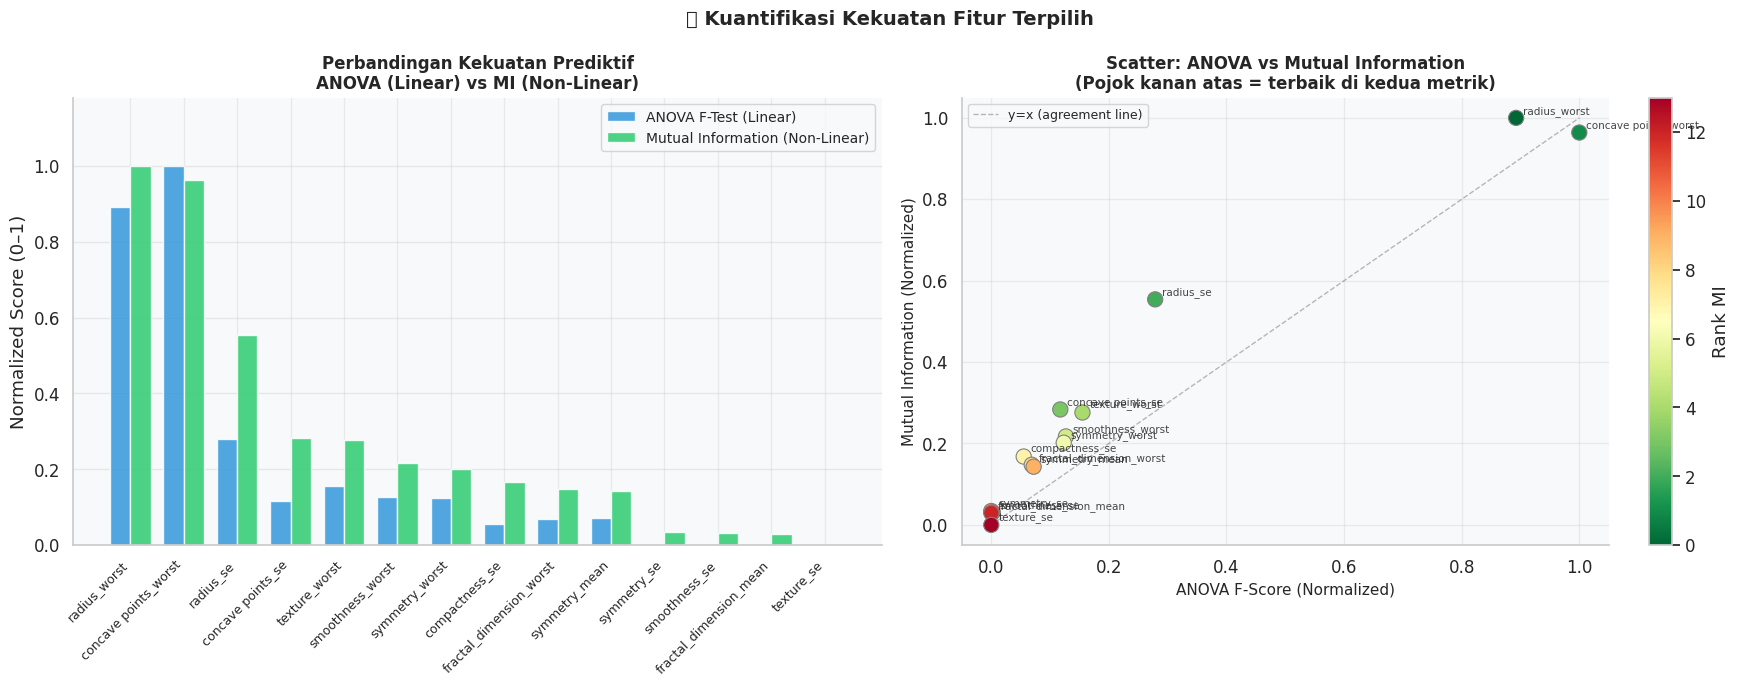

✅ ANOVA vs MI analysis selesai.


In [68]:
print("⏳ Menghitung ANOVA F-Test & Mutual Information...")

X_for_mi = df_enc[selected_features]
y_for_mi = df_enc[TARGET_COL]

f_vals, p_vals   = f_classif(X_for_mi, y_for_mi)
mi_vals          = mutual_info_classif(X_for_mi, y_for_mi, random_state=SEED)

score_df = pd.DataFrame({
    'Feature'    : selected_features,
    'ANOVA_F'    : f_vals,
    'p_value'    : p_vals,
    'MI_Score'   : mi_vals
})

# Normalisasi untuk perbandingan visual
mm = MinMaxScaler()
score_df[['ANOVA_norm', 'MI_norm']] = mm.fit_transform(score_df[['ANOVA_F', 'MI_Score']])
score_df = score_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("\n📊 Tabel Skor (urut MI Score):")
display(score_df[['Feature', 'ANOVA_F', 'p_value', 'MI_Score']].style
    .background_gradient(cmap='Greens', subset=['MI_Score'])
    .background_gradient(cmap='Blues', subset=['ANOVA_F'])
    .format({'ANOVA_F': '{:.2f}', 'p_value': '{:.4f}', 'MI_Score': '{:.4f}'})
)

# Visualisasi
x_pos = np.arange(len(score_df))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart ganda — ANOVA vs MI
ax = axes[0]
ax.bar(x_pos - width/2, score_df['ANOVA_norm'], width,
       label='ANOVA F-Test (Linear)', color='#3498db', edgecolor='white', alpha=0.85)
ax.bar(x_pos + width/2, score_df['MI_norm'], width,
       label='Mutual Information (Non-Linear)', color='#2ecc71', edgecolor='white', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(score_df['Feature'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalized Score (0–1)')
ax.set_title('Perbandingan Kekuatan Prediktif\nANOVA (Linear) vs MI (Non-Linear)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.18)
ax.grid(axis='y', alpha=0.4)

# Scatter plot ANOVA vs MI
ax2 = axes[1]
scatter = ax2.scatter(score_df['ANOVA_norm'], score_df['MI_norm'],
                      c=np.arange(len(score_df)), cmap='RdYlGn_r',
                      s=120, edgecolors='gray', linewidths=0.8, zorder=3)
for _, row in score_df.iterrows():
    ax2.annotate(row['Feature'], (row['ANOVA_norm'], row['MI_norm']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7.5, alpha=0.85)
ax2.set_xlabel('ANOVA F-Score (Normalized)', fontsize=11)
ax2.set_ylabel('Mutual Information (Normalized)', fontsize=11)
ax2.set_title('Scatter: ANOVA vs Mutual Information\n(Pojok kanan atas = terbaik di kedua metrik)',
              fontsize=12, fontweight='bold')
diag = [0, 1]
ax2.plot(diag, diag, 'k--', alpha=0.3, linewidth=1, label='y=x (agreement line)')
ax2.legend(fontsize=9)
plt.colorbar(scatter, ax=ax2, label='Rank MI')

fig.suptitle('🔬 Kuantifikasi Kekuatan Fitur Terpilih', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ ANOVA vs MI analysis selesai.")

## ⚗️ SECTION 11: Transformasi Yeo-Johnson (Before vs After per Batch)

⏳ Transformasi Yeo-Johnson pada fitur terpilih...
✅ Yeo-Johnson selesai untuk 14 fitur.

📊 Before vs After Skewness:


,Fitur,Skew_Before,Skew_After,Improvement
2,radius_se,3.089,0.195,2.894
10,smoothness_se,2.314,0.084,2.230
13,symmetry_se,2.195,0.136,2.059
9,compactness_se,1.902,0.205,1.697
8,fractal_dimension_worst,1.663,0.082,1.581
12,texture_se,1.646,0.013,1.633
6,concave points_se,1.445,-0.038,1.407
5,symmetry_worst,1.434,-0.053,1.381
11,fractal_dimension_mean,1.304,0.036,1.268
1,radius_worst,1.103,0.034,1.069


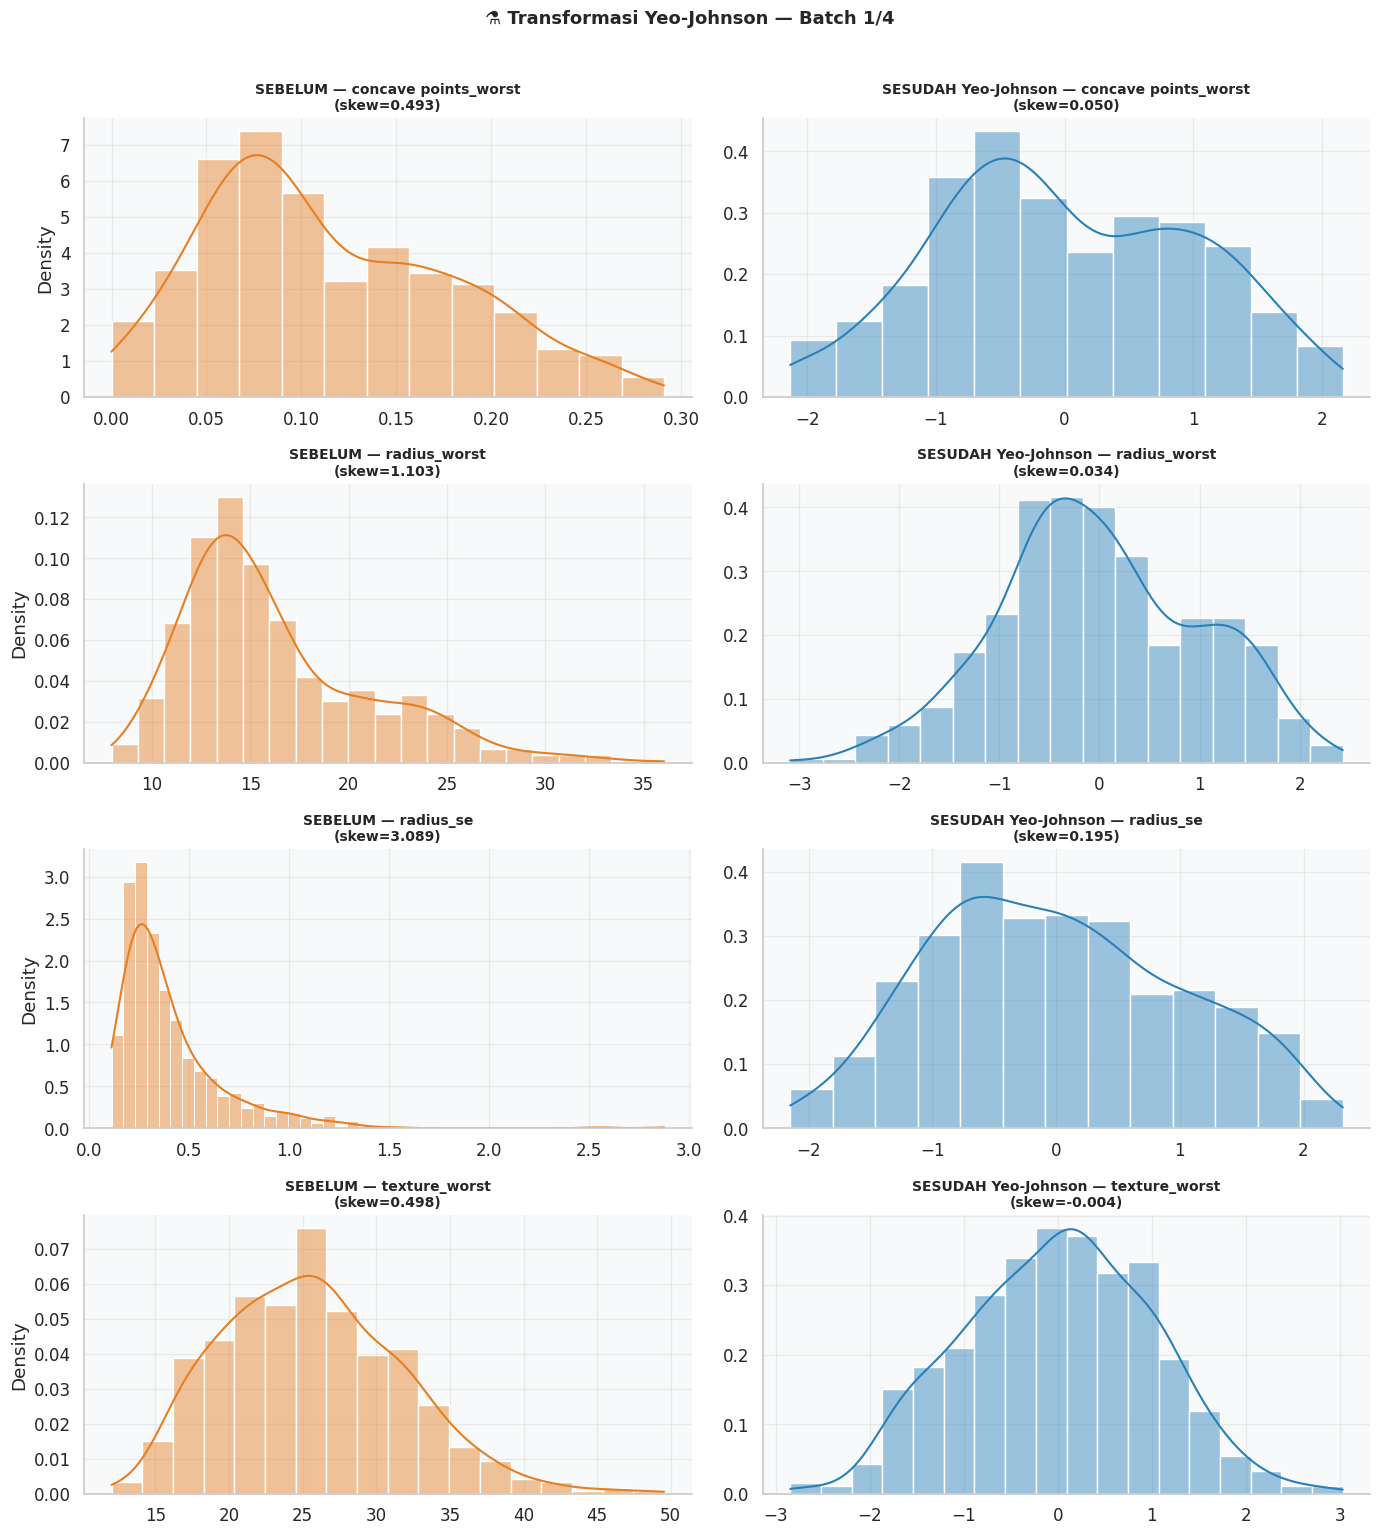

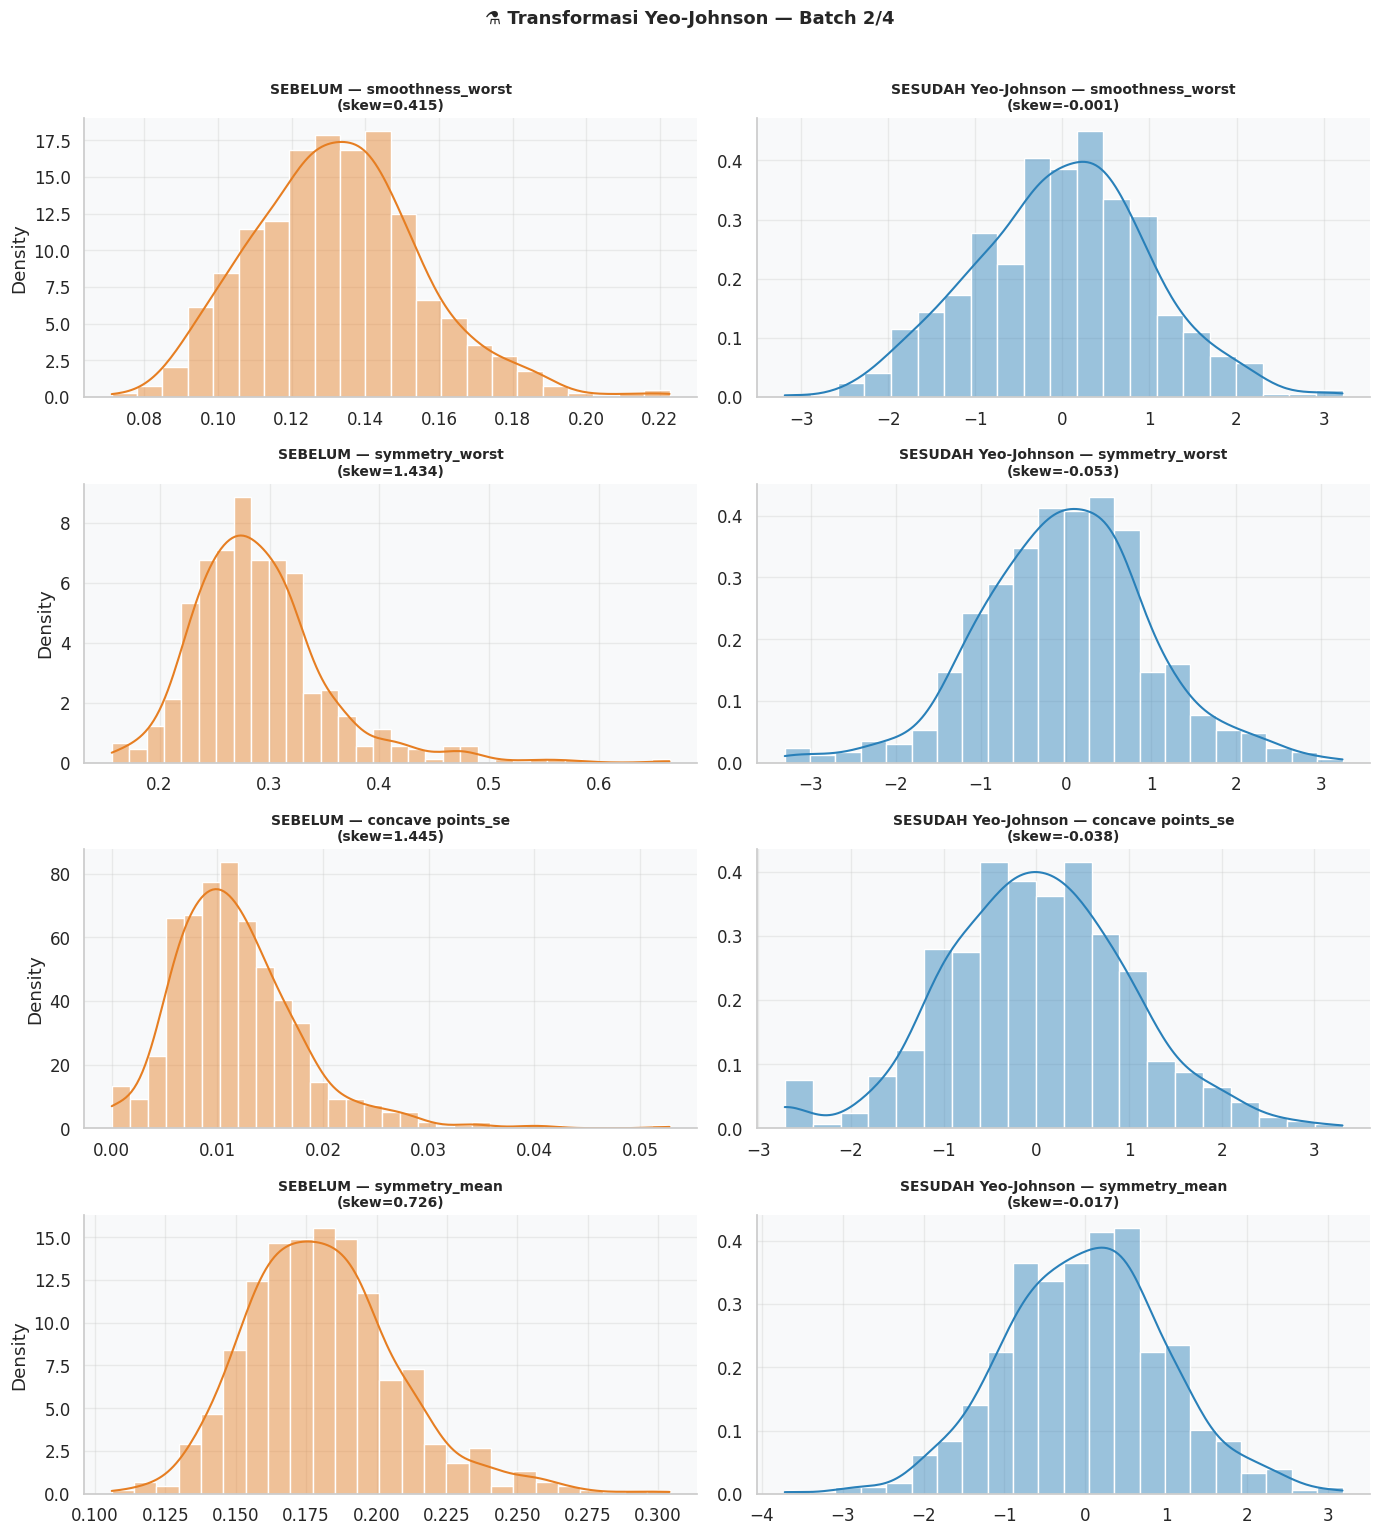

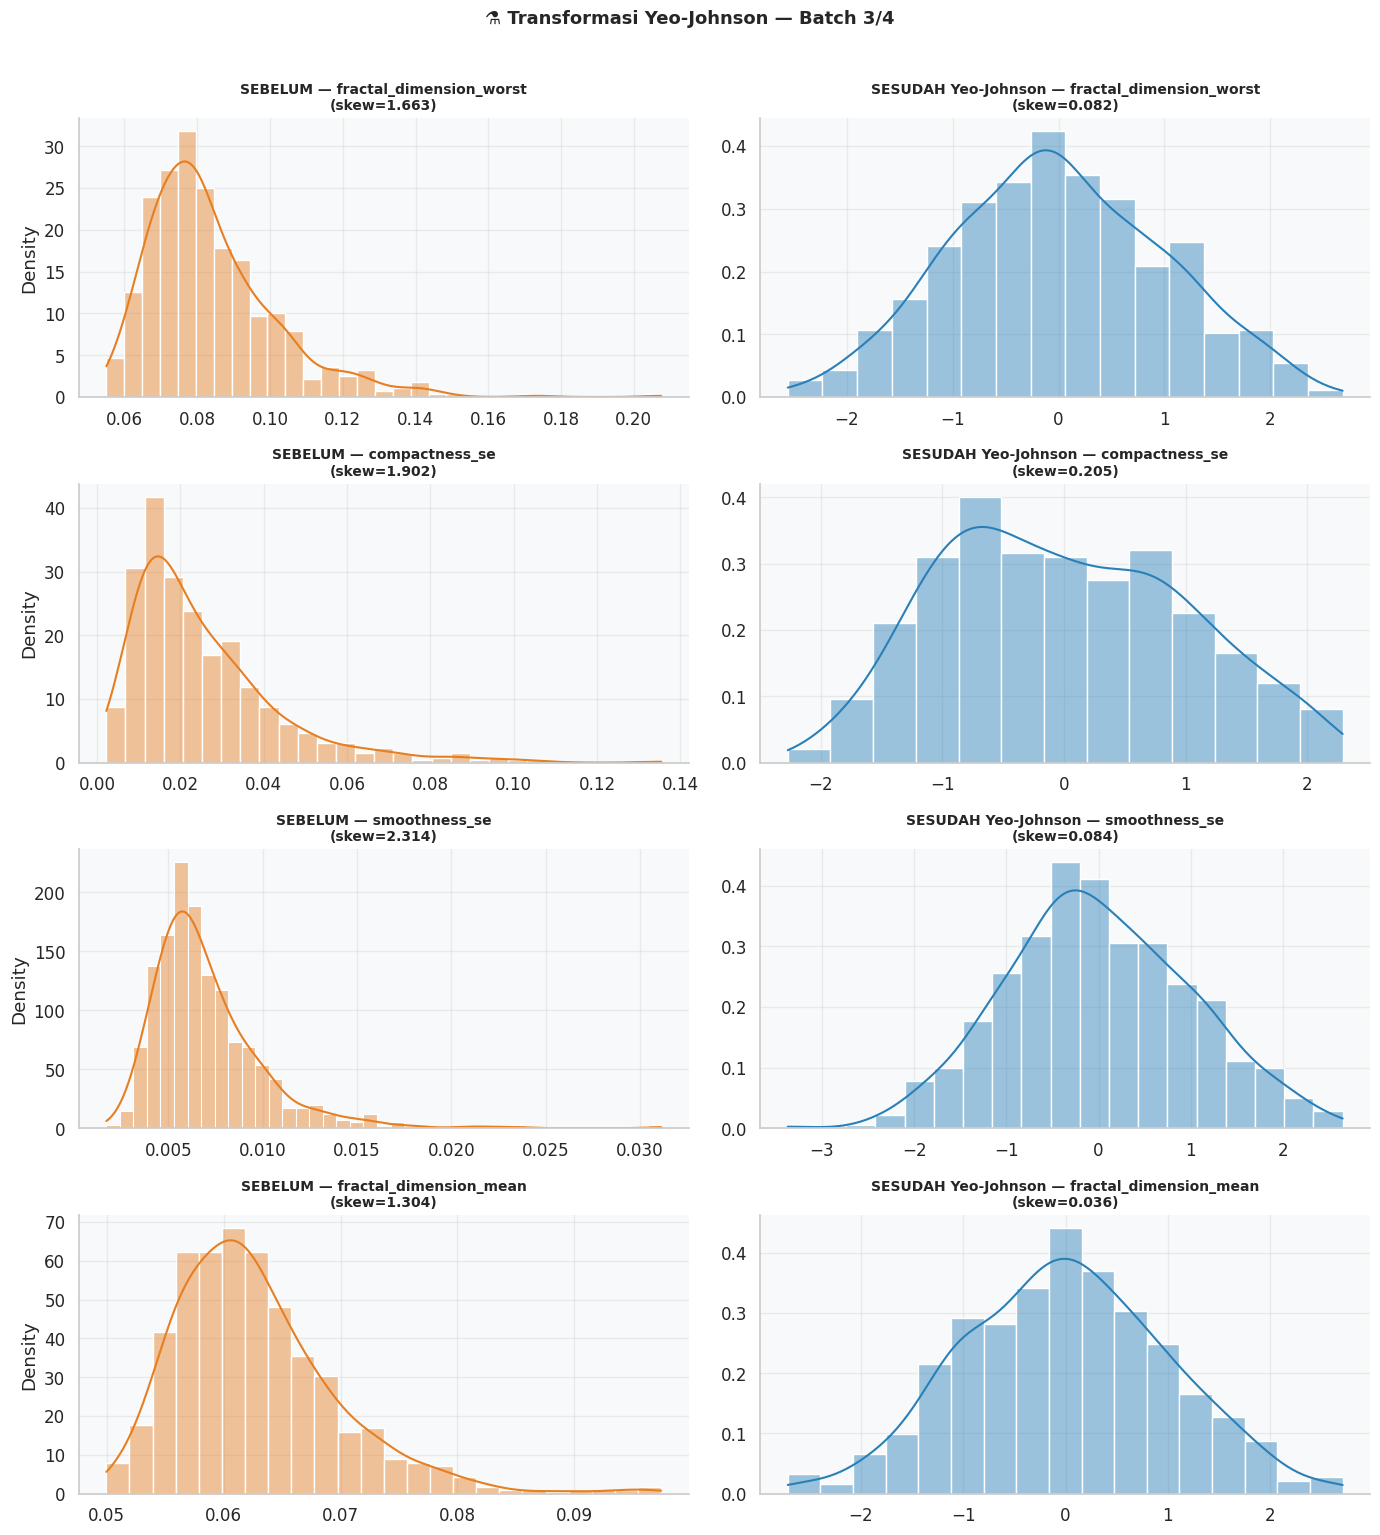

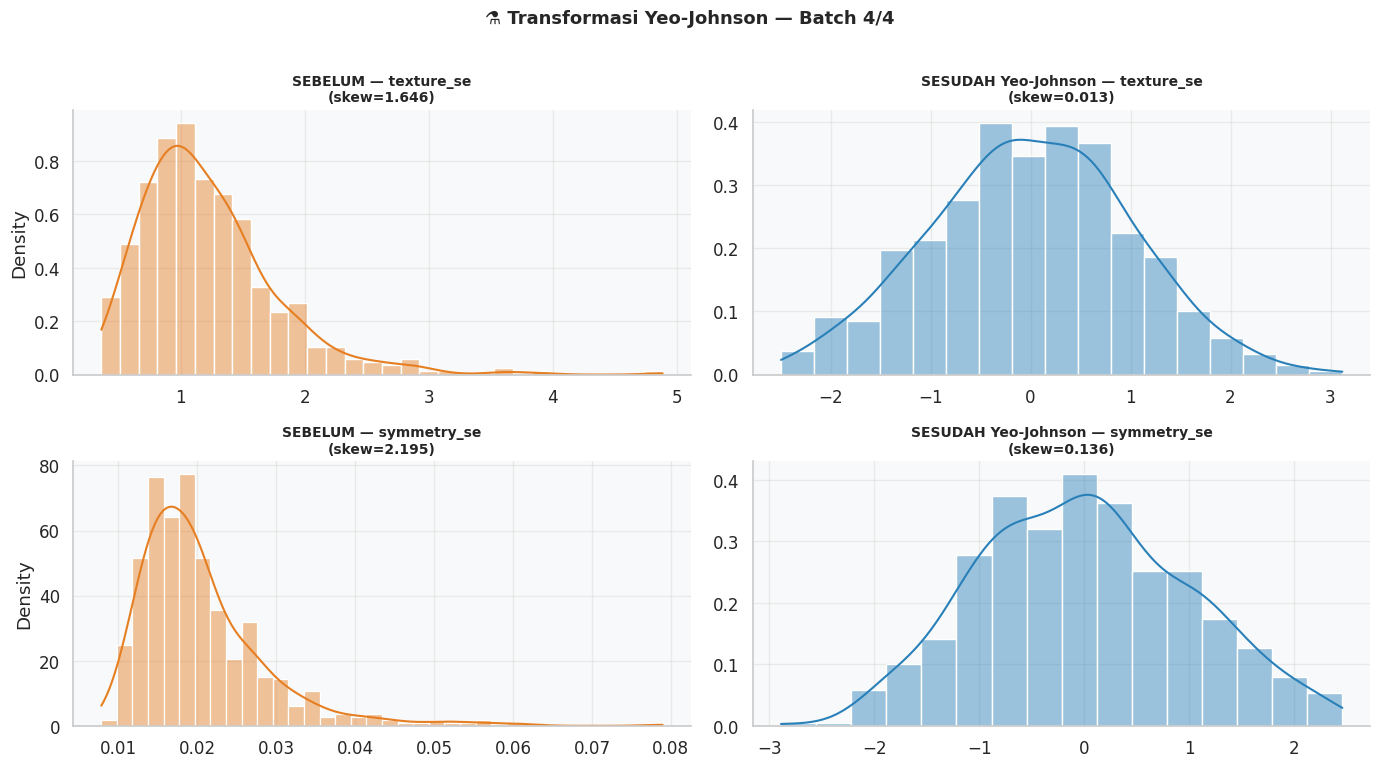

✅ Visualisasi Yeo-Johnson selesai.


In [69]:
print("⏳ Transformasi Yeo-Johnson pada fitur terpilih...")

X_raw   = df[selected_features].copy()
y_label = df[TARGET_COL].copy()

pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_transformed = pt.fit_transform(X_raw)
df_transformed = pd.DataFrame(X_transformed, columns=selected_features)
df_transformed[TARGET_COL] = y_label.values

print(f"✅ Yeo-Johnson selesai untuk {len(selected_features)} fitur.")
print("\n📊 Before vs After Skewness:")

skew_comparison = pd.DataFrame({
    'Fitur'         : selected_features,
    'Skew_Before'   : X_raw.skew().values,
    'Skew_After'    : df_transformed[selected_features].skew().values
})
skew_comparison['Improvement'] = abs(skew_comparison['Skew_Before']) - abs(skew_comparison['Skew_After'])
skew_comparison = skew_comparison.sort_values('Skew_Before', ascending=False)
display(skew_comparison.style
    .background_gradient(cmap='RdYlGn', subset=['Improvement'])
    .format(precision=3)
)

# Visualisasi Before vs After
batch_size_t = 4
n_batches_t  = math.ceil(len(selected_features) / batch_size_t)

for bi in range(n_batches_t):
    batch = selected_features[bi * batch_size_t : (bi + 1) * batch_size_t]
    n_b = len(batch)

    fig, axes = plt.subplots(n_b, 2, figsize=(14, 3.8 * n_b))
    if n_b == 1:
        axes = np.array([axes])

    for j, feat in enumerate(batch):
        # BEFORE
        sns.histplot(X_raw[feat], kde=True, ax=axes[j, 0],
                     color='#e67e22', stat='density', alpha=0.45)
        axes[j, 0].set_title(f"SEBELUM — {feat}\n(skew={X_raw[feat].skew():.3f})",
                              fontweight='bold', fontsize=10)
        axes[j, 0].set_ylabel('Density')
        axes[j, 0].set_xlabel('')

        # AFTER
        sns.histplot(df_transformed[feat], kde=True, ax=axes[j, 1],
                     color='#2980b9', stat='density', alpha=0.45)
        axes[j, 1].set_title(
            f"SESUDAH Yeo-Johnson — {feat}\n(skew={df_transformed[feat].skew():.3f})",
            fontweight='bold', fontsize=10)
        axes[j, 1].set_ylabel('')
        axes[j, 1].set_xlabel('')

    fig.suptitle(f"⚗️ Transformasi Yeo-Johnson — Batch {bi+1}/{n_batches_t}",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("✅ Visualisasi Yeo-Johnson selesai.")

## 🔵 SECTION 12: PCA Visualization (2D + 3D Scatter)

PC1 Explained Variance : 35.02%
PC2 Explained Variance : 18.28%
PC3 Explained Variance : 14.28%
Total (PC1+PC2+PC3)    : 67.58%


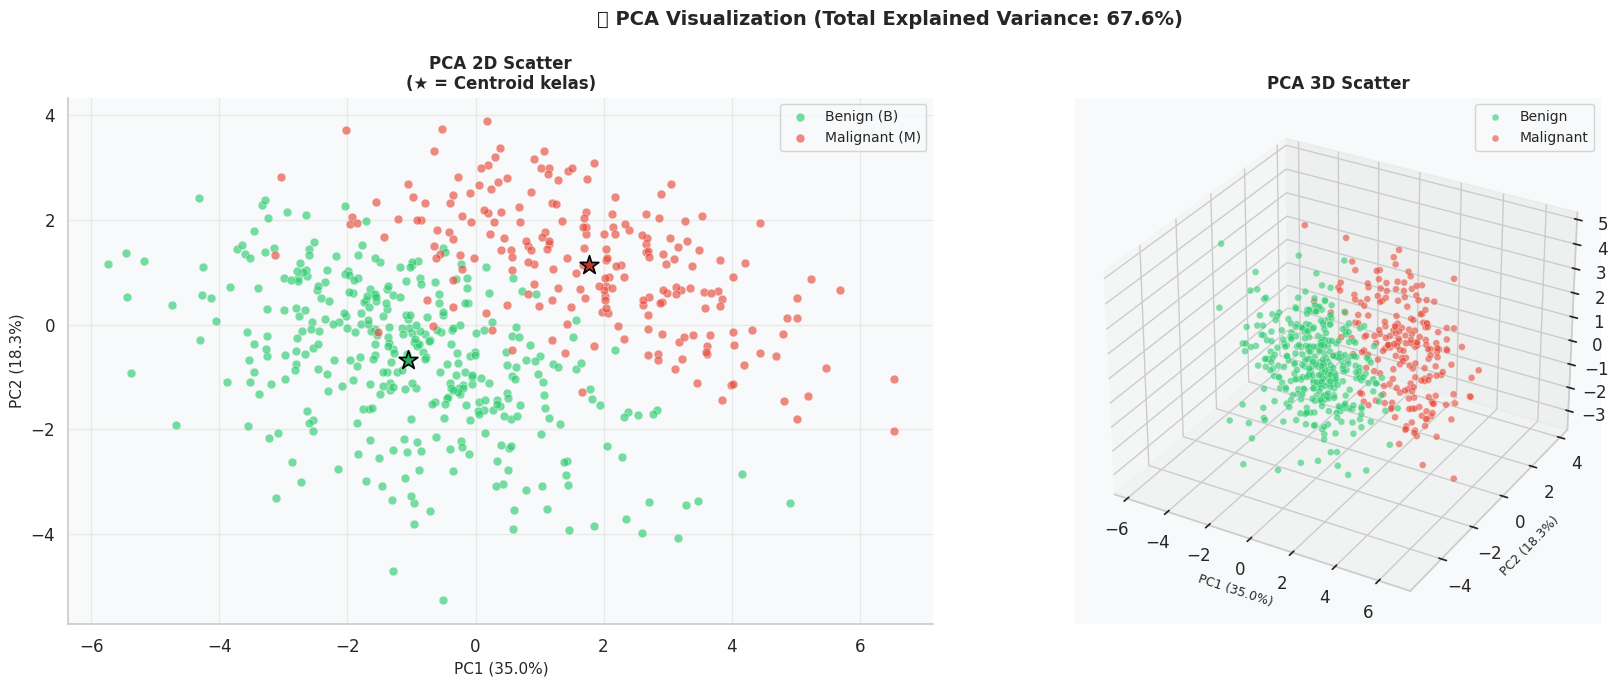

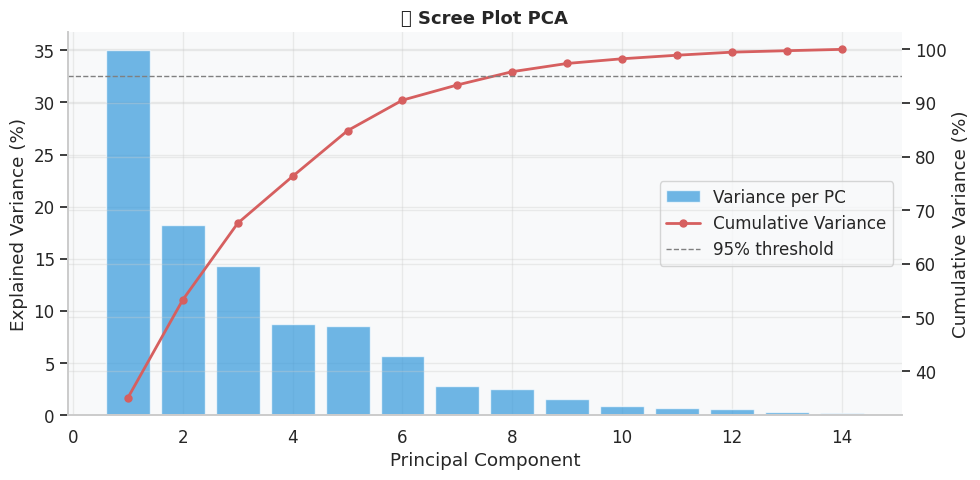

✅ PCA Visualization selesai.


In [70]:
# PCA dari data transformed
X_pca_input = df_transformed[selected_features].values
y_pca       = df_transformed[TARGET_COL].map({'B': 0, 'M': 1}).values
y_colors    = ['#2ecc71' if yi == 0 else '#e74c3c' for yi in y_pca]

pca3 = PCA(n_components=3, random_state=SEED)
X_pca3 = pca3.fit_transform(X_pca_input)

exp_var = pca3.explained_variance_ratio_ * 100
print(f"PC1 Explained Variance : {exp_var[0]:.2f}%")
print(f"PC2 Explained Variance : {exp_var[1]:.2f}%")
print(f"PC3 Explained Variance : {exp_var[2]:.2f}%")
print(f"Total (PC1+PC2+PC3)    : {sum(exp_var):.2f}%")

fig = plt.figure(figsize=(18, 7))

# ── 2D Scatter (PC1 vs PC2) ──────────────────────────────
ax1 = fig.add_subplot(121)
for label_val, label_name, color in [(0, 'Benign (B)', '#2ecc71'), (1, 'Malignant (M)', '#e74c3c')]:
    mask = y_pca == label_val
    ax1.scatter(X_pca3[mask, 0], X_pca3[mask, 1],
                c=color, label=label_name, alpha=0.65, s=40,
                edgecolors='white', linewidths=0.4)

# Centroid
for label_val, color in [(0, '#27ae60'), (1, '#c0392b')]:
    mask = y_pca == label_val
    cx, cy = X_pca3[mask, 0].mean(), X_pca3[mask, 1].mean()
    ax1.scatter(cx, cy, c=color, s=200, marker='*', zorder=5,
                edgecolors='black', linewidths=1.2)

ax1.set_xlabel(f'PC1 ({exp_var[0]:.1f}%)', fontsize=11)
ax1.set_ylabel(f'PC2 ({exp_var[1]:.1f}%)', fontsize=11)
ax1.set_title('PCA 2D Scatter\n(★ = Centroid kelas)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, framealpha=0.8)

# ── 3D Scatter (PC1, PC2, PC3) ───────────────────────────
ax2 = fig.add_subplot(122, projection='3d')
for label_val, label_name, color in [(0, 'Benign', '#2ecc71'), (1, 'Malignant', '#e74c3c')]:
    mask = y_pca == label_val
    ax2.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
                c=color, label=label_name, alpha=0.6, s=25,
                edgecolors='white', linewidths=0.3)

ax2.set_xlabel(f'PC1 ({exp_var[0]:.1f}%)', fontsize=9)
ax2.set_ylabel(f'PC2 ({exp_var[1]:.1f}%)', fontsize=9)
ax2.set_zlabel(f'PC3 ({exp_var[2]:.1f}%)', fontsize=9)
ax2.set_title('PCA 3D Scatter', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

fig.suptitle(f'🔵 PCA Visualization (Total Explained Variance: {sum(exp_var):.1f}%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Scree Plot ────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_pca_input)
cumvar = np.cumsum(pca_full.explained_variance_ratio_ * 100)

fig2, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
       pca_full.explained_variance_ratio_*100,
       color='#3498db', alpha=0.7, label='Variance per PC')
ax2b = ax.twinx()
ax2b.plot(range(1, len(cumvar)+1), cumvar, 'r-o', markersize=5,
          linewidth=2, label='Cumulative Variance')
ax2b.axhline(95, color='gray', linestyle='--', linewidth=1, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax2b.set_ylabel('Cumulative Variance (%)')
ax.set_title('📊 Scree Plot PCA', fontsize=13, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()
print("✅ PCA Visualization selesai.")

## 🔗 SECTION 13: Pairplot Top-5 Fitur Terpilih

🔗 Pairplot untuk 5 fitur teratas: ['concave points_worst', 'radius_worst', 'radius_se', 'texture_worst', 'smoothness_worst']


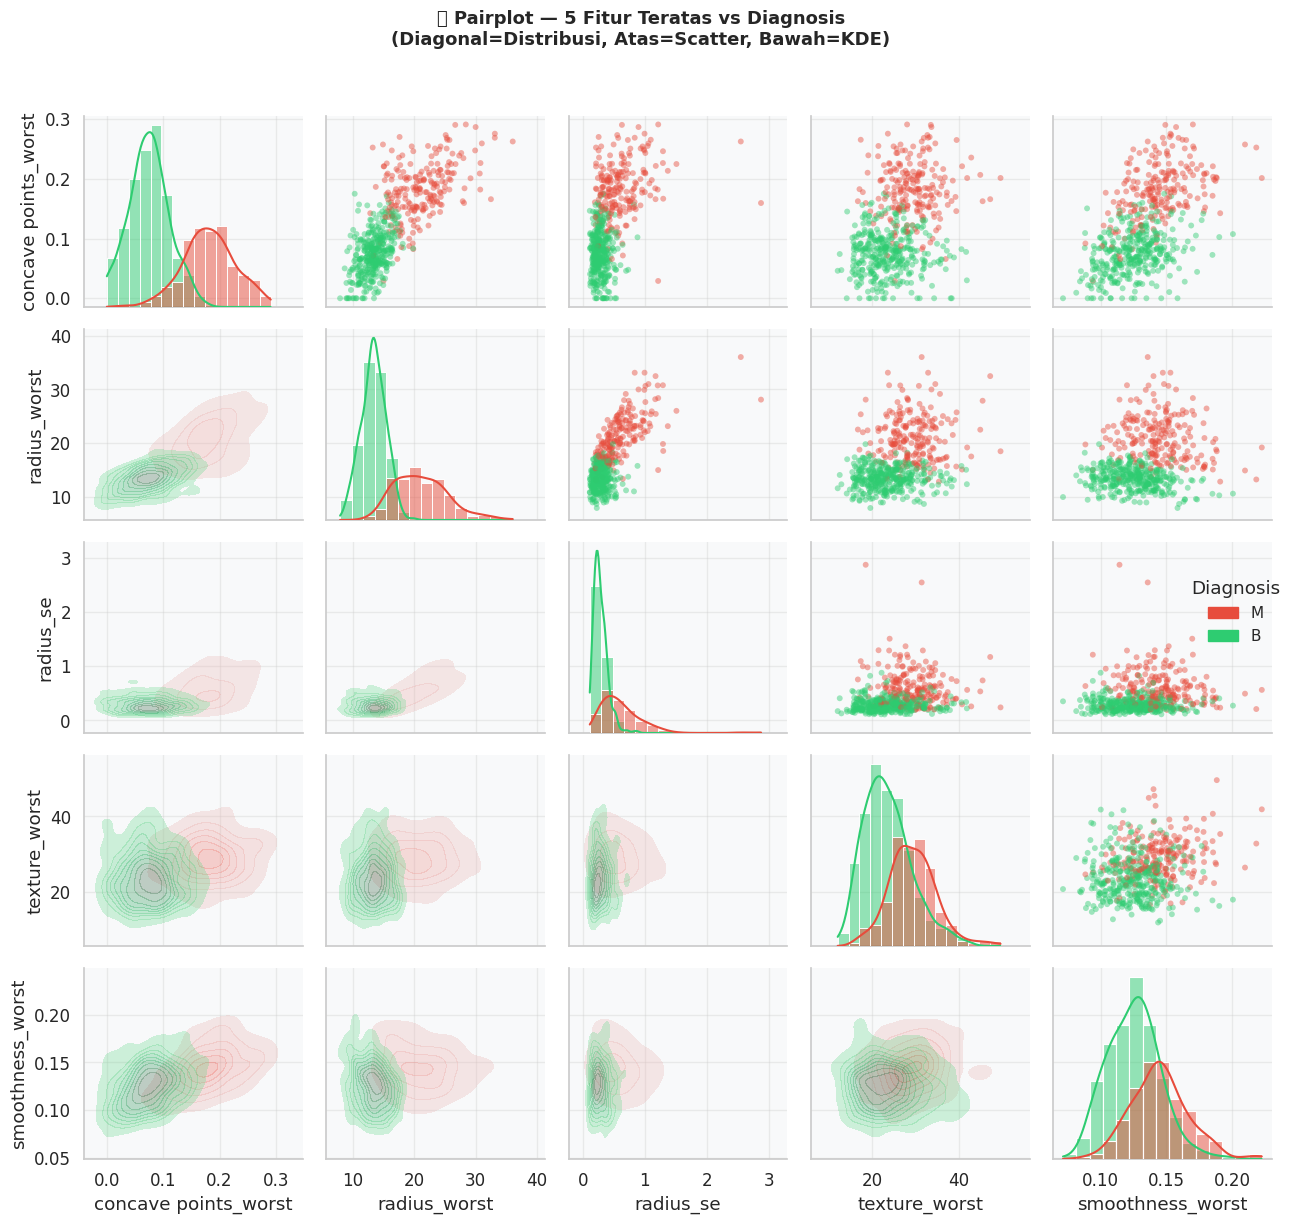

✅ Pairplot selesai.


In [71]:
top5_feats = selected_features[:5]
print(f"🔗 Pairplot untuk 5 fitur teratas: {top5_feats}")

pair_df = df[top5_feats + [TARGET_COL]].copy()

g = sns.PairGrid(pair_df, hue=TARGET_COL, palette={'B': '#2ecc71', 'M': '#e74c3c'},
                 diag_sharey=False, height=2.4, aspect=1)
g.map_upper(sns.scatterplot, alpha=0.45, s=18, edgecolors='none')
g.map_lower(sns.kdeplot, fill=True, alpha=0.3, warn_singular=False)
g.map_diag(sns.histplot, kde=True, stat='density', alpha=0.5, bins=15)
g.add_legend(fontsize=11, title='Diagnosis', title_fontsize=11)
g.figure.suptitle('🔗 Pairplot — 5 Fitur Teratas vs Diagnosis\n'
                   '(Diagonal=Distribusi, Atas=Scatter, Bawah=KDE)',
                   fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✅ Pairplot selesai.")

## 🏋️ SECTION 14: Preprocessing — SMOTE & Scaling

In [72]:
# ════════════════════════════════════════════════════════════
#  PREPROCESSING PIPELINE
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("🏋️  PREPROCESSING PIPELINE")
print("=" * 60)

# ── Data Siap (transformed + selected features) ───────────
X_ready = df_transformed[selected_features].values
y_ready = df_transformed[TARGET_COL].map({'B': 0, 'M': 1}).values.astype(int)

print(f"\n[1] Dataset Input:")
print(f"    Shape: {X_ready.shape}")
print(f"    Kelas: Benign={sum(y_ready==0)}, Malignant={sum(y_ready==1)}")

# ── Stratified Manual Split ───────────────────────────────
def stratified_split(X, y, test_size=0.25, random_state=42):
    np.random.seed(random_state)
    classes = np.unique(y)
    train_idx, test_idx = [], []
    for cls in classes:
        idx = np.where(y == cls)[0]
        np.random.shuffle(idx)
        n_test = int(len(idx) * test_size)
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])
    train_idx = np.array(train_idx)
    test_idx  = np.array(test_idx)
    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = stratified_split(X_ready, y_ready, test_size=0.25)

print(f"\n[2] Train-Test Split (Stratified 75/25):")
print(f"    Train → Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}, Total: {len(y_train)}")
print(f"    Test  → Benign: {sum(y_test==0)},  Malignant: {sum(y_test==1)},  Total: {len(y_test)}")

# ── SMOTE (hanya di training set!) ───────────────────────
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\n[3] SMOTE (hanya training set):")
print(f"    Sebelum → Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}")
print(f"    Sesudah → Benign: {sum(y_train_res==0)}, Malignant: {sum(y_train_res==1)}")

# ── Standard Scaling ──────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)   # fit hanya di train!
X_test_sc  = scaler.transform(X_test)

print(f"\n[4] StandardScaler diterapkan.")
print(f"    X_train shape : {X_train_sc.shape}")
print(f"    X_test shape  : {X_test_sc.shape}")
print("\n✅ Preprocessing selesai!")

# Simpan untuk dipakai semua model
N_FEATURES = X_train_sc.shape[1]

🏋️  PREPROCESSING PIPELINE

[1] Dataset Input:
    Shape: (569, 14)
    Kelas: Benign=357, Malignant=212

[2] Train-Test Split (Stratified 75/25):
    Train → Benign: 268, Malignant: 159, Total: 427
    Test  → Benign: 89,  Malignant: 53,  Total: 142

[3] SMOTE (hanya training set):
    Sebelum → Benign: 268, Malignant: 159
    Sesudah → Benign: 268, Malignant: 268

[4] StandardScaler diterapkan.
    X_train shape : (536, 14)
    X_test shape  : (142, 14)

✅ Preprocessing selesai!


## ⚡ SECTION 15: Model Training — XGBoost (GPU)

In [73]:
print("=" * 60)
print(f"⚡  XGBoost Training [Device: {XGB_DEVICE.upper()}]")
print("=" * 60)

t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators   = 300,
    max_depth      = 6,
    learning_rate  = 0.05,
    subsample      = 0.8,
    colsample_bytree=0.8,
    gamma          = 0.1,
    reg_alpha      = 0.1,
    reg_lambda     = 1.0,
    min_child_weight=3,
    use_label_encoder=False,
    eval_metric    = 'logloss',
    device         = XGB_DEVICE,     # 'cuda' atau 'cpu'
    random_state   = SEED,
    verbosity      = 0
)

xgb_model.fit(
    X_train_sc, y_train_res,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)
xgb_time = time.time() - t0

y_pred_xgb  = xgb_model.predict(X_test_sc)
y_prob_xgb  = xgb_model.predict_proba(X_test_sc)[:, 1]

print(f"\n✅ XGBoost Training selesai dalam {xgb_time:.2f} detik")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"   F1 Score : {f1_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Benign', 'Malignant']))

⚡  XGBoost Training [Device: CUDA]

✅ XGBoost Training selesai dalam 0.66 detik
   Accuracy : 94.37%
   F1 Score : 92.45%

📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        89
   Malignant       0.92      0.92      0.92        53

    accuracy                           0.94       142
   macro avg       0.94      0.94      0.94       142
weighted avg       0.94      0.94      0.94       142



## 🌲 SECTION 16: Model Training — Random Forest

In [74]:
print("=" * 60)
if CUML_AVAILABLE:
    print("🌲  Random Forest Training [cuML — GPU]")
else:
    print("🌲  Random Forest Training [sklearn — CPU]")
print("=" * 60)

t0 = time.time()
if CUML_AVAILABLE:
    rf_model = cuRF(
        n_estimators=300, max_depth=10,
        max_features='sqrt', random_state=SEED
    )
else:
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED,
        oob_score=True
    )

rf_model.fit(X_train_sc, y_train_res)
rf_time = time.time() - t0

y_pred_rf = rf_model.predict(X_test_sc)
y_prob_rf  = rf_model.predict_proba(X_test_sc)[:, 1]

print(f"\n✅ Random Forest selesai dalam {rf_time:.2f} detik")
if not CUML_AVAILABLE and hasattr(rf_model, 'oob_score_'):
    print(f"   OOB Score   : {rf_model.oob_score_*100:.2f}%")
print(f"   Accuracy    : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"   F1 Score    : {f1_score(y_test, y_pred_rf)*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malignant']))

🌲  Random Forest Training [sklearn — CPU]

✅ Random Forest selesai dalam 0.43 detik
   OOB Score   : 96.64%
   Accuracy    : 95.77%
   F1 Score    : 94.34%

📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        89
   Malignant       0.94      0.94      0.94        53

    accuracy                           0.96       142
   macro avg       0.95      0.95      0.95       142
weighted avg       0.96      0.96      0.96       142



## 🎯 SECTION 17: Model Training — SVM

In [75]:
print("=" * 60)
if CUML_AVAILABLE:
    print("🎯  SVM Training [cuML — GPU]")
else:
    print("🎯  SVM Training [sklearn — CPU]")
print("=" * 60)

t0 = time.time()
if CUML_AVAILABLE:
    svm_model = cuSVC(
        C=10.0, kernel='rbf', gamma='scale',
        probability=True, random_state=SEED
    )
else:
    svm_model = SVC(
        C=10.0,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=SEED
    )

svm_model.fit(X_train_sc, y_train_res)
svm_time = time.time() - t0

y_pred_svm = svm_model.predict(X_test_sc)
y_prob_svm  = svm_model.predict_proba(X_test_sc)[:, 1]

print(f"\n✅ SVM selesai dalam {svm_time:.2f} detik")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print(f"   F1 Score : {f1_score(y_test, y_pred_svm)*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Benign', 'Malignant']))

🎯  SVM Training [sklearn — CPU]

✅ SVM selesai dalam 0.01 detik
   Accuracy : 95.77%
   F1 Score : 94.34%

📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        89
   Malignant       0.94      0.94      0.94        53

    accuracy                           0.96       142
   macro avg       0.95      0.95      0.95       142
weighted avg       0.96      0.96      0.96       142



## 🧠 SECTION 18: Model Training — ANN (PyTorch, GPU)

In [76]:
print("=" * 60)
print(f"🧠  ANN Training [PyTorch — {str(DEVICE).upper()}]")
print("=" * 60)

# ── Model Architecture ────────────────────────────────────
class BreastCancerANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)   # Logit output (BCEWithLogitsLoss)
        )

    def forward(self, x):
        return self.net(x)

# ── Tensors → GPU ─────────────────────────────────────────
X_tr_t = torch.FloatTensor(X_train_sc).to(DEVICE)
X_te_t = torch.FloatTensor(X_test_sc).to(DEVICE)
y_tr_t = torch.FloatTensor(y_train_res).unsqueeze(1).to(DEVICE)
y_te_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

# ── Weighted Sampler (tambahan keseimbangan kelas) ────────
class_counts  = np.bincount(y_train_res)
class_weights = 1.0 / class_counts
sample_weights= class_weights[y_train_res]
sampler = WeightedRandomSampler(torch.FloatTensor(sample_weights),
                                 len(sample_weights), replacement=True)

train_ds = TensorDataset(X_tr_t, y_tr_t)
loader   = DataLoader(train_ds, batch_size=32, sampler=sampler)

# ── Loss & Optimizer ──────────────────────────────────────
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

ann_model  = BreastCancerANN(N_FEATURES).to(DEVICE)
optimizer  = optim.AdamW(ann_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150, eta_min=1e-5)

print(f"\nArsitektur ANN:")
print(ann_model)
total_params = sum(p.numel() for p in ann_model.parameters())
print(f"\nTotal Parameters : {total_params:,}")

# ── Training Loop ─────────────────────────────────────────
EPOCHS = 20
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss = float('inf')
best_state    = None
t0 = time.time()

for ep in range(EPOCHS):
    ann_model.train()
    ep_loss, correct, total_n = 0, 0, 0

    for Xb, yb in loader:
        optimizer.zero_grad()
        out  = ann_model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ann_model.parameters(), max_norm=1.0)
        optimizer.step()
        ep_loss += loss.item()
        pred     = (torch.sigmoid(out) >= 0.5).float()
        correct += (pred == yb).sum().item()
        total_n += yb.size(0)

    train_losses.append(ep_loss / len(loader))
    train_accs.append(correct / total_n)

    ann_model.eval()
    with torch.no_grad():
        val_logit = ann_model(X_te_t)
        val_loss  = criterion(val_logit, y_te_t).item()
        val_pred  = (torch.sigmoid(val_logit) >= 0.5).float()
        val_acc   = (val_pred == y_te_t).float().mean().item()

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        import copy
        best_state = copy.deepcopy(ann_model.state_dict())

    if (ep + 1) % 25 == 0:
        print(f"  Epoch [{ep+1:3d}/{EPOCHS}] "
              f"Train Loss={train_losses[-1]:.4f} Acc={train_accs[-1]:.4f} | "
              f"Val Loss={val_loss:.4f} Acc={val_acc:.4f} | "
              f"LR={scheduler.get_last_lr()[0]:.6f}")

ann_time = time.time() - t0

# Load best model
ann_model.load_state_dict(best_state)
ann_model.eval()

with torch.no_grad():
    y_prob_ann_t = torch.sigmoid(ann_model(X_te_t)).cpu().numpy().flatten()
y_pred_ann = (y_prob_ann_t >= 0.5).astype(int)
y_prob_ann = y_prob_ann_t

print(f"\n✅ ANN selesai dalam {ann_time:.2f} detik (best val_loss={best_val_loss:.4f})")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_ann)*100:.2f}%")
print(f"   F1 Score : {f1_score(y_test, y_pred_ann)*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_ann, target_names=['Benign', 'Malignant']))

🧠  ANN Training [PyTorch — CUDA]

Arsitektur ANN:
BreastCancerANN(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): ReLU()
    (14): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total Parameters : 13,249

✅ ANN selesai dalam 1.46 detik (best val_loss=0.1169)
   Accuracy : 

## 📉 SECTION 19: ANN Learning Curves

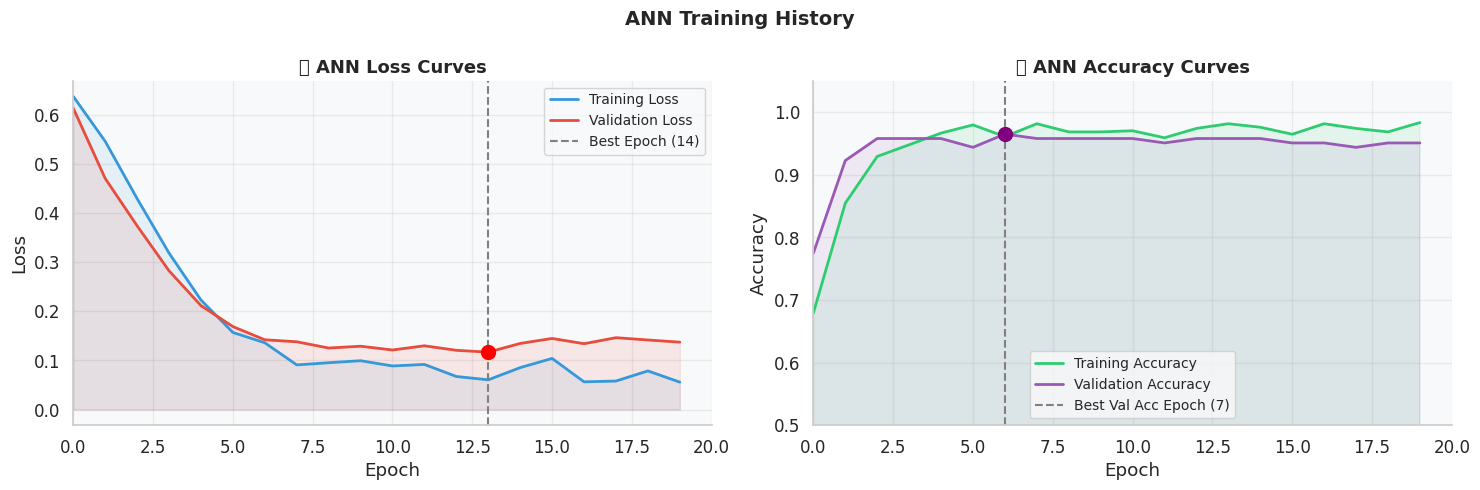

✅ Learning curves selesai.


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax = axes[0]
ax.plot(train_losses, label='Training Loss', color='#3498db', linewidth=2)
ax.plot(val_losses,   label='Validation Loss', color='#e74c3c', linewidth=2)
ax.fill_between(range(len(train_losses)), train_losses, alpha=0.1, color='#3498db')
ax.fill_between(range(len(val_losses)),   val_losses,   alpha=0.1, color='#e74c3c')
best_ep = np.argmin(val_losses)
ax.axvline(best_ep, color='gray', linestyle='--', linewidth=1.5,
           label=f'Best Epoch ({best_ep+1})')
ax.scatter([best_ep], [val_losses[best_ep]], color='red', s=100, zorder=5)
ax.set_title('📉 ANN Loss Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=10)
ax.set_xlim(0, EPOCHS)

# Accuracy curves
ax2 = axes[1]
ax2.plot(train_accs, label='Training Accuracy', color='#2ecc71', linewidth=2)
ax2.plot(val_accs,   label='Validation Accuracy', color='#9b59b6', linewidth=2)
ax2.fill_between(range(len(train_accs)), train_accs, alpha=0.1, color='#2ecc71')
ax2.fill_between(range(len(val_accs)),   val_accs,   alpha=0.1, color='#9b59b6')
best_acc_ep = np.argmax(val_accs)
ax2.axvline(best_acc_ep, color='gray', linestyle='--', linewidth=1.5,
            label=f'Best Val Acc Epoch ({best_acc_ep+1})')
ax2.scatter([best_acc_ep], [val_accs[best_acc_ep]], color='purple', s=100, zorder=5)
ax2.set_title('🎯 ANN Accuracy Curves', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=10)
ax2.set_xlim(0, EPOCHS)
ax2.set_ylim(0.5, 1.05)

fig.suptitle('ANN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Learning curves selesai.")

## 📊 SECTION 20: Evaluasi — Confusion Matrices (Semua Model)

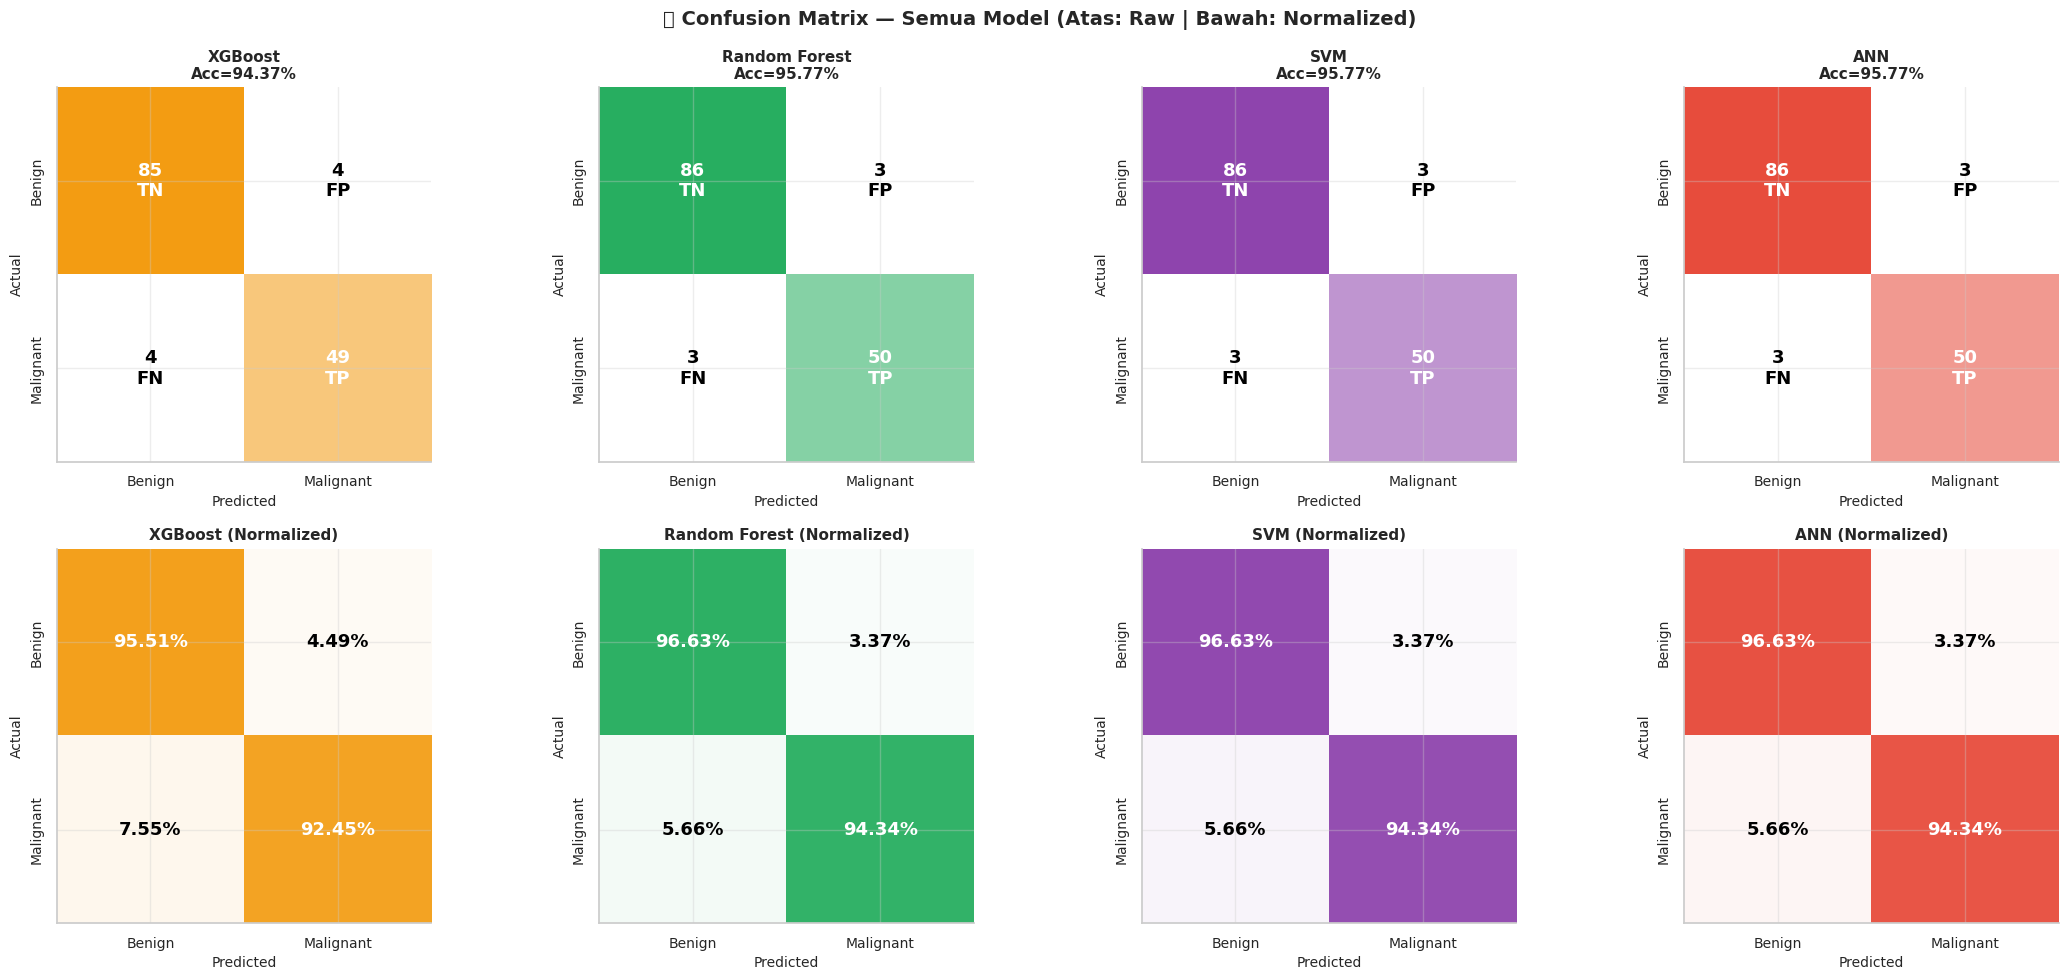

✅ Confusion matrices selesai.


In [78]:
models_eval = [
    ('XGBoost',       y_pred_xgb,  y_prob_xgb,  '#f39c12'),
    ('Random Forest', y_pred_rf,   y_prob_rf,   '#27ae60'),
    ('SVM',           y_pred_svm,  y_prob_svm,  '#8e44ad'),
    ('ANN',           y_pred_ann,  y_prob_ann,  '#e74c3c'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for col, (name, y_pred, y_prob, color) in enumerate(models_eval):
    cm = confusion_matrix(y_test, y_pred)
    TP = cm[1,1]; TN = cm[0,0]; FP = cm[0,1]; FN = cm[1,0]
    acc = accuracy_score(y_test, y_pred)

    # Raw confusion matrix
    ax = axes[0, col]
    cmap_custom = LinearSegmentedColormap.from_list('cm_cmap', ['#ffffff', color])
    im = ax.imshow(cm, cmap=cmap_custom, interpolation='nearest')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benign', 'Malignant'], fontsize=10)
    ax.set_yticklabels(['Benign', 'Malignant'], fontsize=10, rotation=90, va='center')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title(f'{name}\nAcc={acc*100:.2f}%', fontsize=11, fontweight='bold')
    thresh = cm.max() / 2.0
    for r in range(2):
        for c in range(2):
            label = f'{cm[r,c]}\n{"TP" if r==1 and c==1 else "TN" if r==0 and c==0 else "FP" if r==0 and c==1 else "FN"}'
            ax.text(c, r, label, ha='center', va='center', fontsize=13,
                    fontweight='bold',
                    color='white' if cm[r,c] > thresh else 'black')

    # Normalized confusion matrix
    ax2 = axes[1, col]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im2 = ax2.imshow(cm_norm, cmap=cmap_custom, vmin=0, vmax=1, interpolation='nearest')
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(['Benign', 'Malignant'], fontsize=10)
    ax2.set_yticklabels(['Benign', 'Malignant'], fontsize=10, rotation=90, va='center')
    ax2.set_xlabel('Predicted', fontsize=10)
    ax2.set_ylabel('Actual', fontsize=10)
    ax2.set_title(f'{name} (Normalized)', fontsize=11, fontweight='bold')
    for r in range(2):
        for c in range(2):
            ax2.text(c, r, f'{cm_norm[r,c]:.2%}', ha='center', va='center',
                     fontsize=13, fontweight='bold',
                     color='white' if cm_norm[r,c] > 0.5 else 'black')

fig.suptitle('📊 Confusion Matrix — Semua Model (Atas: Raw | Bawah: Normalized)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Confusion matrices selesai.")

## 📈 SECTION 21: ROC Curves + PR Curves (Semua Model)

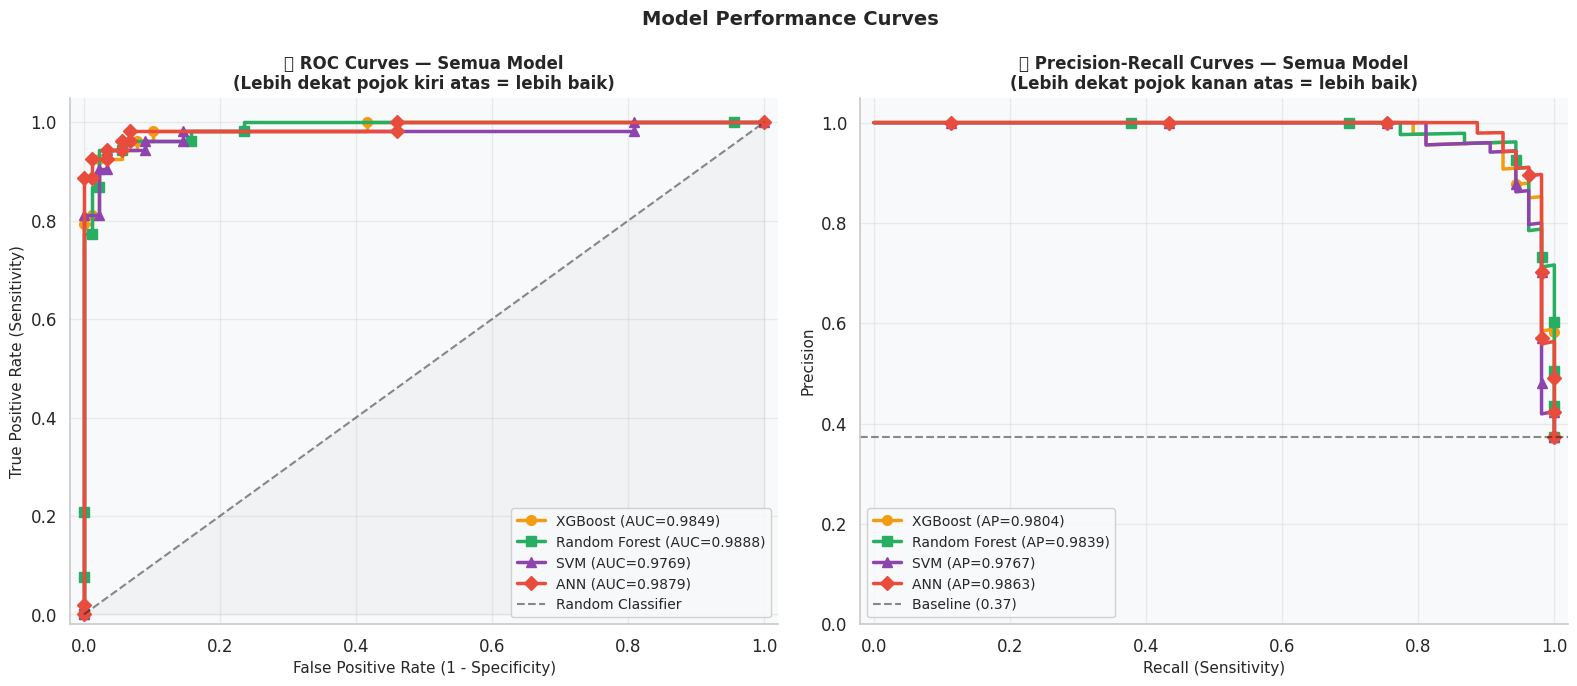

✅ ROC & PR Curves selesai.


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

model_colors = ['#f39c12', '#27ae60', '#8e44ad', '#e74c3c']
model_markers = ['o', 's', '^', 'D']

# ── ROC Curves ────────────────────────────────────────────
ax_roc = axes[0]
for (name, y_pred, y_prob, _), color, marker in zip(models_eval, model_colors, model_markers):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2.5, marker=marker,
                markevery=max(1, len(fpr)//8), markersize=7,
                label=f'{name} (AUC={roc_auc:.4f})')

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')
ax_roc.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax_roc.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax_roc.set_title('📈 ROC Curves — Semua Model\n(Lebih dekat pojok kiri atas = lebih baik)',
                  fontsize=12, fontweight='bold')
ax_roc.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax_roc.set_xlim(-0.02, 1.02)
ax_roc.set_ylim(-0.02, 1.05)

# ── Precision-Recall Curves ───────────────────────────────
ax_pr = axes[1]
n_positive = sum(y_test == 1)
baseline   = n_positive / len(y_test)

for (name, y_pred, y_prob, _), color, marker in zip(models_eval, model_colors, model_markers):
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax_pr.plot(rec, prec, color=color, linewidth=2.5, marker=marker,
               markevery=max(1, len(rec)//8), markersize=7,
               label=f'{name} (AP={ap:.4f})')

ax_pr.axhline(baseline, color='k', linestyle='--', linewidth=1.5, alpha=0.5,
              label=f'Baseline ({baseline:.2f})')
ax_pr.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax_pr.set_ylabel('Precision', fontsize=11)
ax_pr.set_title('📉 Precision-Recall Curves — Semua Model\n(Lebih dekat pojok kanan atas = lebih baik)',
                 fontsize=12, fontweight='bold')
ax_pr.legend(fontsize=10, loc='lower left', framealpha=0.9)
ax_pr.set_xlim(-0.02, 1.02)
ax_pr.set_ylim(0.0, 1.05)

fig.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ ROC & PR Curves selesai.")

## 🌟 SECTION 22: Feature Importance (XGBoost + Random Forest)

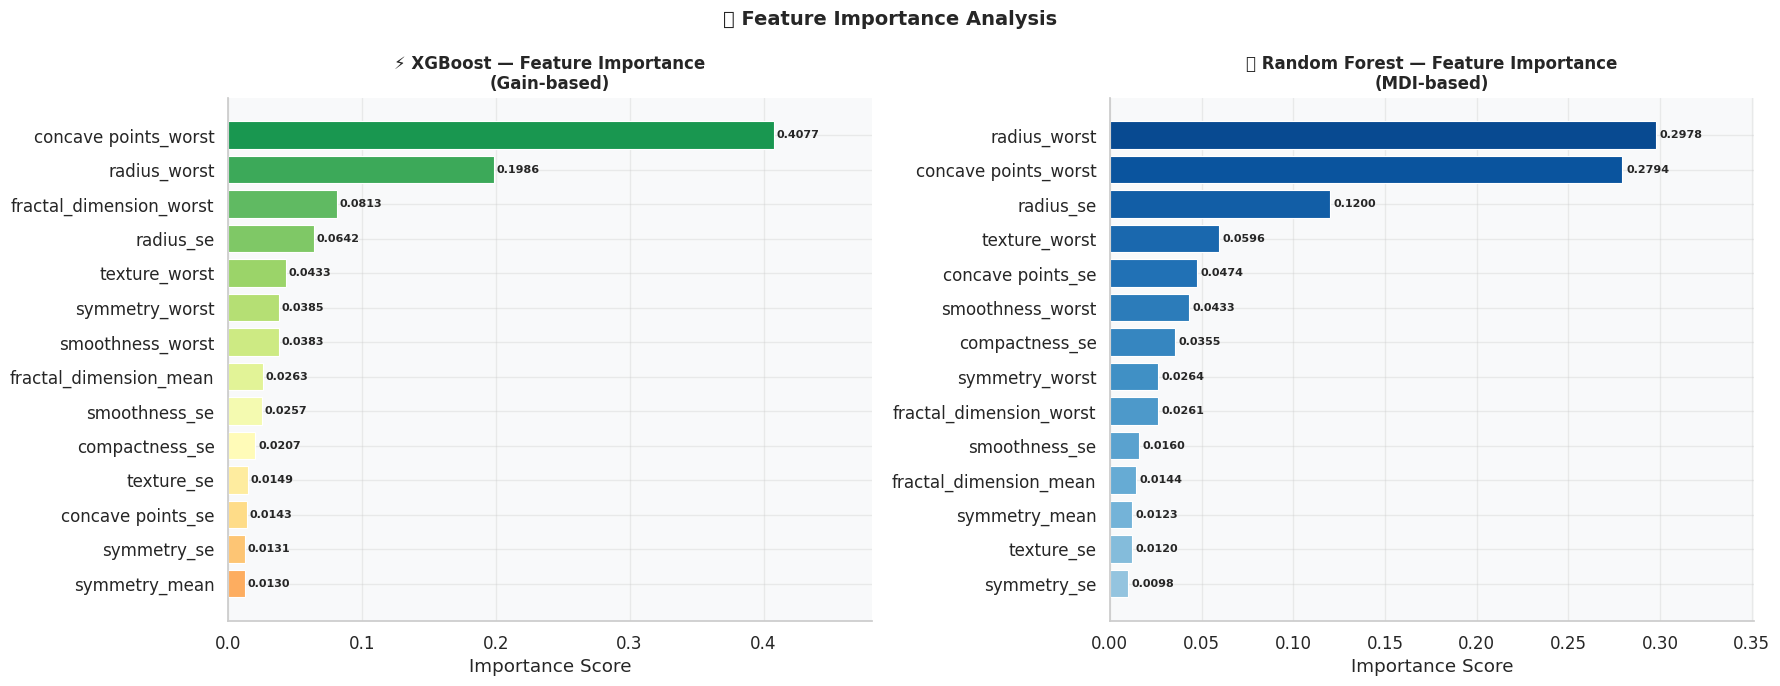

✅ Feature importance selesai.


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── XGBoost Feature Importance ────────────────────────────
ax = axes[0]
xgb_importance = xgb_model.feature_importances_
xgb_fi = pd.Series(xgb_importance, index=selected_features).sort_values(ascending=True)
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(xgb_fi)))
bars = ax.barh(xgb_fi.index, xgb_fi.values, color=colors_fi, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, xgb_fi.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8, fontweight='bold')
ax.set_title('⚡ XGBoost — Feature Importance\n(Gain-based)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, xgb_fi.max() * 1.18)

# ── Random Forest Feature Importance ─────────────────────
ax2 = axes[1]
if not CUML_AVAILABLE:
    rf_importance = rf_model.feature_importances_
    rf_fi = pd.Series(rf_importance, index=selected_features).sort_values(ascending=True)
    colors_fi2 = plt.cm.Blues(np.linspace(0.4, 0.9, len(rf_fi)))
    bars2 = ax2.barh(rf_fi.index, rf_fi.values, color=colors_fi2, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars2, rf_fi.values):
        ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8, fontweight='bold')
    ax2.set_title('🌲 Random Forest — Feature Importance\n(MDI-based)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Importance Score')
    ax2.set_xlim(0, rf_fi.max() * 1.18)
else:
    ax2.text(0.5, 0.5, 'cuML RF Feature Importance\ntidak tersedia secara langsung',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)

fig.suptitle('🌟 Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Feature importance selesai.")

## 🏆 SECTION 23: Model Comparison — Ringkasan Final

🏆  RINGKASAN PERBANDINGAN MODEL

📋 Tabel Metrik:


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Avg Precision,Sensitivity,Specificity,Train Time(s)
Model,,,,,,,,,
XGBoost,0.9437,0.9245,0.9245,0.9245,0.9849,0.9804,0.9245,0.9551,0.66s
Random Forest,0.9577,0.9434,0.9434,0.9434,0.9888,0.9839,0.9434,0.9663,0.43s
SVM,0.9577,0.9434,0.9434,0.9434,0.9769,0.9767,0.9434,0.9663,0.01s
ANN,0.9577,0.9434,0.9434,0.9434,0.9879,0.9863,0.9434,0.9663,1.46s


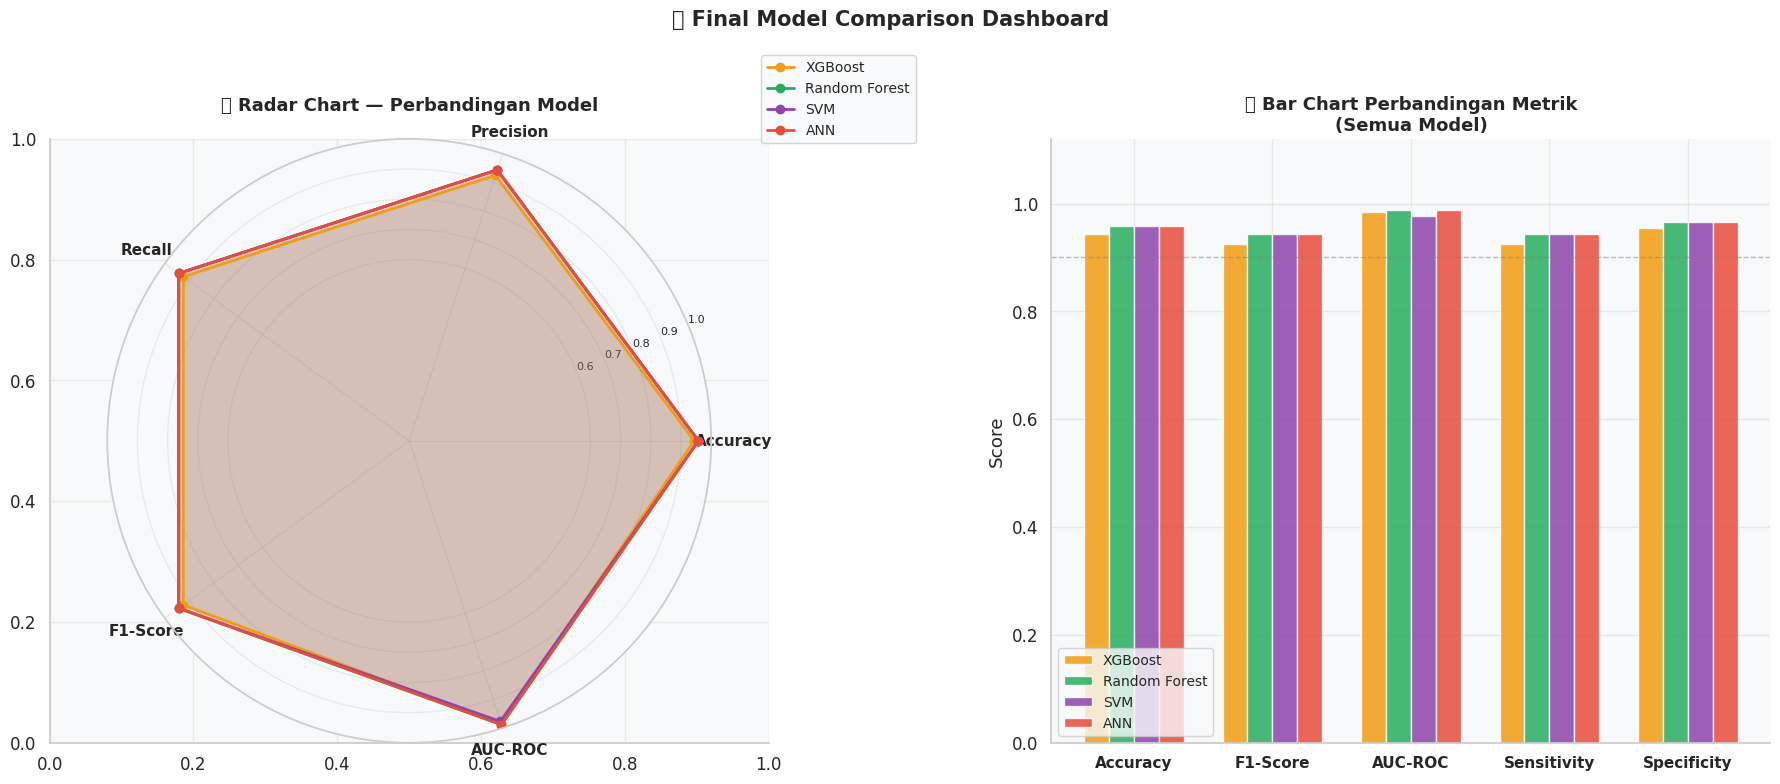


🥇 Model Terbaik (AUC-ROC): Random Forest
   AUC-ROC    : 0.9888
   Accuracy   : 95.77%
   F1-Score   : 0.9434
   Sensitivity: 0.9434
   Specificity: 0.9663

✅ Pipeline MBDA Assignment 1 selesai!


In [81]:
print("=" * 70)
print("🏆  RINGKASAN PERBANDINGAN MODEL")
print("=" * 70)

timing = {
    'XGBoost': xgb_time,
    'Random Forest': rf_time,
    'SVM': svm_time,
    'ANN': ann_time
}

results = []
for name, y_pred, y_prob, _ in models_eval:
    cm_m = confusion_matrix(y_test, y_pred)
    TP = cm_m[1,1]; TN = cm_m[0,0]; FP = cm_m[0,1]; FN = cm_m[1,0]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results.append({
        'Model'       : name,
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred),
        'Recall'      : recall_score(y_test, y_pred),
        'F1-Score'    : f1_score(y_test, y_pred),
        'AUC-ROC'     : auc(fpr, tpr),
        'Avg Precision': average_precision_score(y_test, y_prob),
        'Sensitivity' : TP / (TP + FN) if (TP+FN) > 0 else 0,
        'Specificity' : TN / (TN + FP) if (TN+FP) > 0 else 0,
        'Train Time(s)': timing[name]
    })

results_df = pd.DataFrame(results).set_index('Model')
print("\n📋 Tabel Metrik:")
display(results_df.style
    .background_gradient(cmap='YlGn', subset=['Accuracy','F1-Score','AUC-ROC','Avg Precision'])
    .background_gradient(cmap='RdYlGn', subset=['Sensitivity','Specificity'])
    .background_gradient(cmap='RdYlGn_r', subset=['Train Time(s)'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
        'F1-Score': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Avg Precision': '{:.4f}',
        'Sensitivity': '{:.4f}', 'Specificity': '{:.4f}', 'Train Time(s)': '{:.2f}s'
    })
)

# ── Radar Chart ───────────────────────────────────────────
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
n_metrics = len(metrics_radar)
angles = [n / float(n_metrics) * 2 * np.pi for n in range(n_metrics)]
angles += angles[:1]

fig, axes_r = plt.subplots(1, 2, figsize=(18, 8))

# Radar
ax_radar = fig.add_subplot(121, polar=True)
for (name, y_pred, y_prob, _), color in zip(models_eval, model_colors):
    row = results_df.loc[name]
    vals = [row[m] for m in metrics_radar]
    vals += vals[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2, color=color, label=name)
    ax_radar.fill(angles, vals, alpha=0.12, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics_radar, fontsize=11, fontweight='bold')
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax_radar.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'], fontsize=8)
ax_radar.set_title('🕸️ Radar Chart — Perbandingan Model', fontsize=13,
                    fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

# Bar chart perbandingan
ax_bar = axes_r[1]
metrics_to_plot = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Sensitivity', 'Specificity']
x_pos = np.arange(len(metrics_to_plot))
bar_width = 0.18

for i, (name, _, _, _) in enumerate(models_eval):
    row = results_df.loc[name]
    vals = [row[m] for m in metrics_to_plot]
    ax_bar.bar(x_pos + i * bar_width, vals, bar_width,
               label=name, color=model_colors[i], alpha=0.85, edgecolor='white')

ax_bar.set_xticks(x_pos + bar_width * 1.5)
ax_bar.set_xticklabels(metrics_to_plot, fontsize=11, fontweight='bold')
ax_bar.set_ylabel('Score')
ax_bar.set_title('📊 Bar Chart Perbandingan Metrik\n(Semua Model)',
                  fontsize=13, fontweight='bold')
ax_bar.legend(fontsize=10, loc='lower left')
ax_bar.set_ylim(0, 1.12)
ax_bar.axhline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5,
                label='Target 0.9')
ax_bar.grid(axis='y', alpha=0.4)

fig.suptitle('🏆 Final Model Comparison Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Best model
best_model = results_df['AUC-ROC'].idxmax()
print(f"\n🥇 Model Terbaik (AUC-ROC): {best_model}")
print(f"   AUC-ROC    : {results_df.loc[best_model, 'AUC-ROC']:.4f}")
print(f"   Accuracy   : {results_df.loc[best_model, 'Accuracy']*100:.2f}%")
print(f"   F1-Score   : {results_df.loc[best_model, 'F1-Score']:.4f}")
print(f"   Sensitivity: {results_df.loc[best_model, 'Sensitivity']:.4f}")
print(f"   Specificity: {results_df.loc[best_model, 'Specificity']:.4f}")
print("\n✅ Pipeline MBDA Assignment 1 selesai!")

---
## 💡 Catatan: Penggunaan PyQt6 untuk Interactive Display

Untuk menampilkan plot secara **interaktif dengan window PyQt6**, gunakan salah satu opsi berikut:

### Opsi A — di Jupyter Notebook (widget interaktif):
```python
# Jalankan cell ini SEBELUM import matplotlib.pyplot
# Anda harus install: pip install ipympl
%matplotlib widget
```

### Opsi B — PyQt6 Native Window (di luar Jupyter, sebagai script .py):
```python
import matplotlib
matplotlib.use('QtAgg')  # Menggunakan PyQt6 backend
import matplotlib.pyplot as plt

# Semua plt.show() akan membuka window interaktif PyQt6
# yang bisa di-zoom, di-pan, dan di-save
plt.show(block=True)
```

### Opsi C — Plotly (interaktif HTML dalam Jupyter):
```python
import plotly.express as px
import plotly.graph_objects as go
# Plotly lebih mudah untuk Jupyter interaktif (hover, zoom, filter)
```

> **Rekomendasi:** Untuk tugas kuliah di Jupyter, gunakan `%matplotlib widget` (ipympl). Untuk demo PyQt6, export ke `.py` dan gunakan `matplotlib.use('QtAgg')`.